# Benchmark run analysis

Comparing benchmark runs

In [40]:
import pandas as pd
import numpy as np
from pathlib import Path

In [41]:
RUN_A = 'store/phlag/gaussian/w50k_s40k'
RUN_B = 'store/phlag/gaussian/w250k_s200k'

run_dir_a = Path(RUN_A)
run_dir_b = Path(RUN_B)

runs_path_a = run_dir_a / "runs.tsv"
runs_path_b = run_dir_b / "runs.tsv"

In [42]:
df_a = pd.read_csv(runs_path_a, sep="\t")
df_b = pd.read_csv(runs_path_b, sep="\t")

In [43]:
PATH_COLUMNS = ["report_path"]
PANEL_COLUMNS = ["in_panel_a", "in_panel_b", "in_panel_relerr", "in_panel_em_divergence", "anomaly_fraction_source"]
ID_COLUMNS = ["run_id", "source_leaf", 'x_variable']

df_a = df_a.drop(columns=PATH_COLUMNS + PANEL_COLUMNS+ID_COLUMNS, errors="ignore")
df_b = df_b.drop(columns=PATH_COLUMNS + PANEL_COLUMNS+ID_COLUMNS, errors="ignore")

In [44]:
df_b.columns

Index(['category', 'subcategory', 'column', 'pattern', 'anomaly_fraction',
       'fraction_bin', 'x_value', 'x_bin', 'branch_length_cu', 'clade_name',
       'clade_number', 'tpr', 'fpr', 'precision', 'f1', 'accuracy', 'roc_auc',
       'tp', 'fp', 'fn', 'tn', 'alt_prop_pred', 'n_windows', 'label_flipped',
       'in_panel_hd_alt', 'hd_bin', 'mean_relerr_agg', 'covar_relerr_agg',
       'em_hd', 'em_gt_hd', 'null_mean_norm', 'null_cov_norm', 'alt_mean_norm',
       'alt_cov_norm', 'pooled_mean_norm', 'pooled_cov_norm',
       'transition_null_to_null', 'transition_null_to_alt',
       'transition_alt_to_null', 'transition_alt_to_alt', 'bic',
       'log_likelihood', 'n_trainable_params', 'clip_activation_count',
       'clip_activation_rate', 'clip_unsafe', 'relerr_ABBA_Null_mean',
       'relerr_ABBA_Null_std', 'relerr_ABBA_Alt_mean', 'relerr_ABBA_Alt_std',
       'relerr_BABA_Null_mean', 'relerr_BABA_Null_std', 'relerr_BABA_Alt_mean',
       'relerr_BABA_Alt_std', 'relerr_AABB_Null_

In [45]:
total = df_b['n_windows'][0]
alt_a = df_a['fp'] + df_a['tp']
alt_b = df_b['fp'] + df_b['tp']
print(np.mean(alt_a / total), np.mean(alt_b / total))

1.2697420634920635 0.3178571428571429


In [46]:
(df_b['pooled_mean_norm'] - df_a['pooled_mean_norm']).unique()

array([0.])

In [47]:
len(df_a[(df_a['transition_null_to_null']==1.0) | (df_a['transition_alt_to_alt']==1.0)])

209

In [48]:
df_a[df_a['em_hd'] < df_a['em_gt_hd']]#[['em_hd', 'em_gt_hd']]

,category,subcategory,column,pattern,anomaly_fraction,fraction_bin,x_value,x_bin,branch_length_cu,clade_name,...,relerr_ABBA_Alt_std,relerr_BABA_Null_mean,relerr_BABA_Null_std,relerr_BABA_Alt_mean,relerr_BABA_Alt_std,relerr_AABB_Null_mean,relerr_AABB_Null_std,relerr_AABB_Alt_mean,relerr_AABB_Alt_std,exclusion
3,10X,down,population size decrease,45-55,0.093,"(0,0.1]",3.872,"(1,5]",3.872,N109,...,0.224,-0.048,-0.052,0.896,0.686,-0.012,-0.058,-0.025,0.032,NaN
5,10X,down,population size decrease,49-51,0.013,"(0,0.1]",3.872,"(1,5]",3.872,N109,...,3.832,0.028,0.101,-1.852,4.097,0.033,0.113,-0.267,2.644,NaN
6,10X,down,population size decrease,37-62,0.247,"(0.1,0.25]",3.341,"(1,5]",3.341,N114,...,-0.003,-0.005,-0.001,0.008,0.000,0.000,0.000,-0.002,0.031,NaN
8,10X,down,population size decrease,42-57,0.147,"(0.1,0.25]",3.341,"(1,5]",3.341,N114,...,-0.045,-0.006,-0.031,-0.003,0.116,-0.004,-0.008,-0.008,0.049,NaN
9,10X,down,population size decrease,45-55,0.093,"(0,0.1]",3.341,"(1,5]",3.341,N114,...,-0.103,-0.032,-0.091,-0.012,0.303,-0.002,0.047,-0.131,0.305,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
665,recombination,up,recombination increase,49-51,0.013,"(0,0.1]",0.048,"(0,0.1]",0.048,N716,...,0.080,0.012,-0.049,-0.107,0.280,0.014,-0.044,0.003,2.159,NaN
666,recombination,up,recombination increase,37-62,0.247,"(0.1,0.25]",0.074,"(0,0.1]",0.074,N717,...,0.233,-0.047,-0.094,0.123,0.074,-0.024,-0.049,-0.113,0.009,NaN
668,recombination,up,recombination increase,42-57,0.147,"(0.1,0.25]",0.074,"(0,0.1]",0.074,N717,...,0.192,0.018,0.046,0.047,-0.073,-0.018,0.009,-0.061,-0.011,NaN
670,recombination,up,recombination increase,47-52,0.047,"(0,0.1]",0.074,"(0,0.1]",0.074,N717,...,0.832,-0.052,-0.058,0.263,0.314,-0.024,-0.071,-0.210,0.023,NaN


In [49]:
a = df_a.groupby(['x_bin'])['f1']
b = df_b.groupby(['x_bin'])['f1']
f1_branch_change_mean = (b.mean() - a.mean()) / a.mean()
print('F1 Mean Relative Change Over Branches\n', f1_branch_change_mean)
f1_branch_change_std = (b.std() - a.std()) / a.std()
print('F1 STD Relative Change Over Branches\n', f1_branch_change_std)

F1 Mean Relative Change Over Branches
 x_bin
(0,0.1]   -0.186795
(0.1,1]   -0.238923
(1,5]     -0.307027
high      -0.180901
low       -0.291125
Name: f1, dtype: float64
F1 STD Relative Change Over Branches
 x_bin
(0,0.1]   -0.085076
(0.1,1]   -0.046717
(1,5]     -0.031380
high      -0.159878
low       -0.236810
Name: f1, dtype: float64


In [50]:
f1_mean_change = (
    df_b.groupby(['category', 'subcategory'])['f1'].mean()
    - df_a.groupby(['category', 'subcategory'])['f1'].mean()
) / df_a.groupby(['category', 'subcategory'])['f1'].mean()
f1_std_change = (
    df_b.groupby(['category', 'subcategory'])['f1'].std()
    - df_a.groupby(['category', 'subcategory'])['f1'].std()
) / df_a.groupby(['category', 'subcategory'])['f1'].std()
print('F1 Relative Mean Change\n', f1_mean_change)
print('F1 Relative STD Change\n', f1_std_change)
# print(df_c.groupby(['category', 'subcategory'])['em_bd'].mean())

F1 Relative Mean Change
 category       subcategory
10X            down          -0.244143
               up            -0.272190
admixture      high          -0.180901
               low           -0.291125
recombination  down          -0.317437
               up            -0.230533
Name: f1, dtype: float64
F1 Relative STD Change
 category       subcategory
10X            down          -0.125485
               up            -0.058192
admixture      high          -0.159878
               low           -0.236810
recombination  down          -0.046352
               up            -0.036219
Name: f1, dtype: float64


In [51]:
print(np.mean(df_a['fp']))
print(np.mean(df_b['fp']))
print(np.mean(df_a['tn']))
print(np.mean(df_b['tn']))
print(np.mean(df_a['fn']))
print(np.mean(df_b['fn']))
print(np.mean(df_a['tp']))
print(np.mean(df_b['tp']))

23.123511904761905
6.840773809523809
107.98958333333333
18.419642857142858
3.6949404761904763
0.7053571428571429
14.96875
2.6949404761904763


In [52]:
filter = 'x_bin'
target = 'f1'
value1 = "(0,0.1]"
value2 = "(0.1,0.25]"
low_drop = np.mean(df_b[df_b[filter]==value1][target] - df_a[df_a[filter]==value1][target])
high_drop = np.mean(df_b[df_b[filter]==value2][target] - df_a[df_a[filter]==value2][target])
print(low_drop, high_drop)

-0.07433783783783783 nan


## Pooled mean / std of EM-fitted values (not relative error)

For each report pair sharing a `run_id` in both runs, read the EM-**Fitted** mean and std per topology (ABBA/BABA/AABB) x state (Null/Alt) from report.tsv lines 20-32. Pool (average) every fitted "mean" value across all topologies/states/report pairs into one `pooled_mean` per run, and every fitted "std" value into one `pooled_std` per run -- no run_a vs run_b comparison, just each run's own pooled fitted statistics.

In [53]:
import math
import re as _re
from bench.benchmark import TOPOLOGY_NAMES, RELERR_STATES

_RE_FITTED_ROW = _re.compile(
    r'^(\w+)\t(Null|Alt)\t(mean|std)\t([-\d.eE+]+|nan)\t([-\d.eE+]+|nan)\t([-\d.eE+]+|nan)\s*$',
    _re.IGNORECASE,
)

def read_fitted_stats(report_path):
    fitted = {}
    with open(report_path) as handle:
        for line in handle:
            m = _RE_FITTED_ROW.match(line.rstrip("\n"))
            if not m:
                continue
            topology, state, statistic, fitted_str, _gt_str, _relerr_str = m.groups()
            try:
                value = float(fitted_str)
            except ValueError:
                continue
            if math.isnan(value):
                continue
            fitted[(topology, state.capitalize(), statistic.lower())] = value
    return fitted

df_a_raw = pd.read_csv(runs_path_a, sep="\t")
df_b_raw = pd.read_csv(runs_path_b, sep="\t")
paired = df_a_raw[["run_id", "report_path"]].merge(
    df_b_raw[["run_id", "report_path"]], on="run_id", suffixes=("_a", "_b")
)

pooled_mean_vals = {"a": [], "b": []}
pooled_std_vals = {"a": [], "b": []}
for _, row in paired.iterrows():
    fitted_by_run = {"a": read_fitted_stats(row["report_path_a"]), "b": read_fitted_stats(row["report_path_b"])}
    for run, fitted in fitted_by_run.items():
        for topo in TOPOLOGY_NAMES:
            for state in RELERR_STATES:
                if (topo, state, "mean") in fitted:
                    pooled_mean_vals[run].append(fitted[(topo, state, "mean")])
                if (topo, state, "std") in fitted:
                    pooled_std_vals[run].append(fitted[(topo, state, "std")])

pooled_fitted_stats = pd.DataFrame([
    {"run": RUN_A, "n_report_pairs": len(paired),
     "pooled_mean": np.mean(pooled_mean_vals["a"]), "pooled_std": np.mean(pooled_std_vals["a"])},
    {"run": RUN_B, "n_report_pairs": len(paired),
     "pooled_mean": np.mean(pooled_mean_vals["b"]), "pooled_std": np.mean(pooled_std_vals["b"])},
])
pooled_fitted_stats.to_csv("runs.tsv", sep="\t", index=False)
pooled_fitted_stats

,run,n_report_pairs,pooled_mean,pooled_std
0,store/phlag/gaussian/w50k_s40k,672,64845.158705,16068.149314
1,store/phlag/gaussian/w250k_s200k,672,320659.400520,44624.981103


In [54]:
from bench.utils import CrossRunAnalysis

cra = CrossRunAnalysis()

## Cross-run PNG-metric grids (multi-config)

### Aggregating by double-variance-init

In [55]:
df_b['category'].unique()

array(['10X', 'admixture', 'recombination'], dtype=object)

In [56]:
df_a.columns

Index(['category', 'subcategory', 'column', 'pattern', 'anomaly_fraction',
       'fraction_bin', 'x_value', 'x_bin', 'branch_length_cu', 'clade_name',
       'clade_number', 'tpr', 'fpr', 'precision', 'f1', 'accuracy', 'roc_auc',
       'tp', 'fp', 'fn', 'tn', 'alt_prop_pred', 'n_windows', 'label_flipped',
       'in_panel_hd_alt', 'hd_bin', 'mean_relerr_agg', 'covar_relerr_agg',
       'em_hd', 'em_gt_hd', 'null_mean_norm', 'null_cov_norm', 'alt_mean_norm',
       'alt_cov_norm', 'pooled_mean_norm', 'pooled_cov_norm',
       'transition_null_to_null', 'transition_null_to_alt',
       'transition_alt_to_null', 'transition_alt_to_alt', 'bic',
       'log_likelihood', 'n_trainable_params', 'clip_activation_count',
       'clip_activation_rate', 'clip_unsafe', 'relerr_ABBA_Null_mean',
       'relerr_ABBA_Null_std', 'relerr_ABBA_Alt_mean', 'relerr_ABBA_Alt_std',
       'relerr_BABA_Null_mean', 'relerr_BABA_Null_std', 'relerr_BABA_Alt_mean',
       'relerr_BABA_Alt_std', 'relerr_AABB_Null_

double-variance-init (9 runs, f1=0.2601):
  step size: 1k,800k,1m
  alt emission parameterization: free,repulsion
  lambda: 1.0,1.5
  annealing
(none) (92 runs, f1=0.4213):
  window size: 10k,50k,100k,250k,500k,1m
  step size: 1k,10k,40k,50k,80k,100k,200k,250k,400k,500k,800k,1m
  alt emission parameterization: free,repulsion
  lambda: 1.0,1.5
  annealing


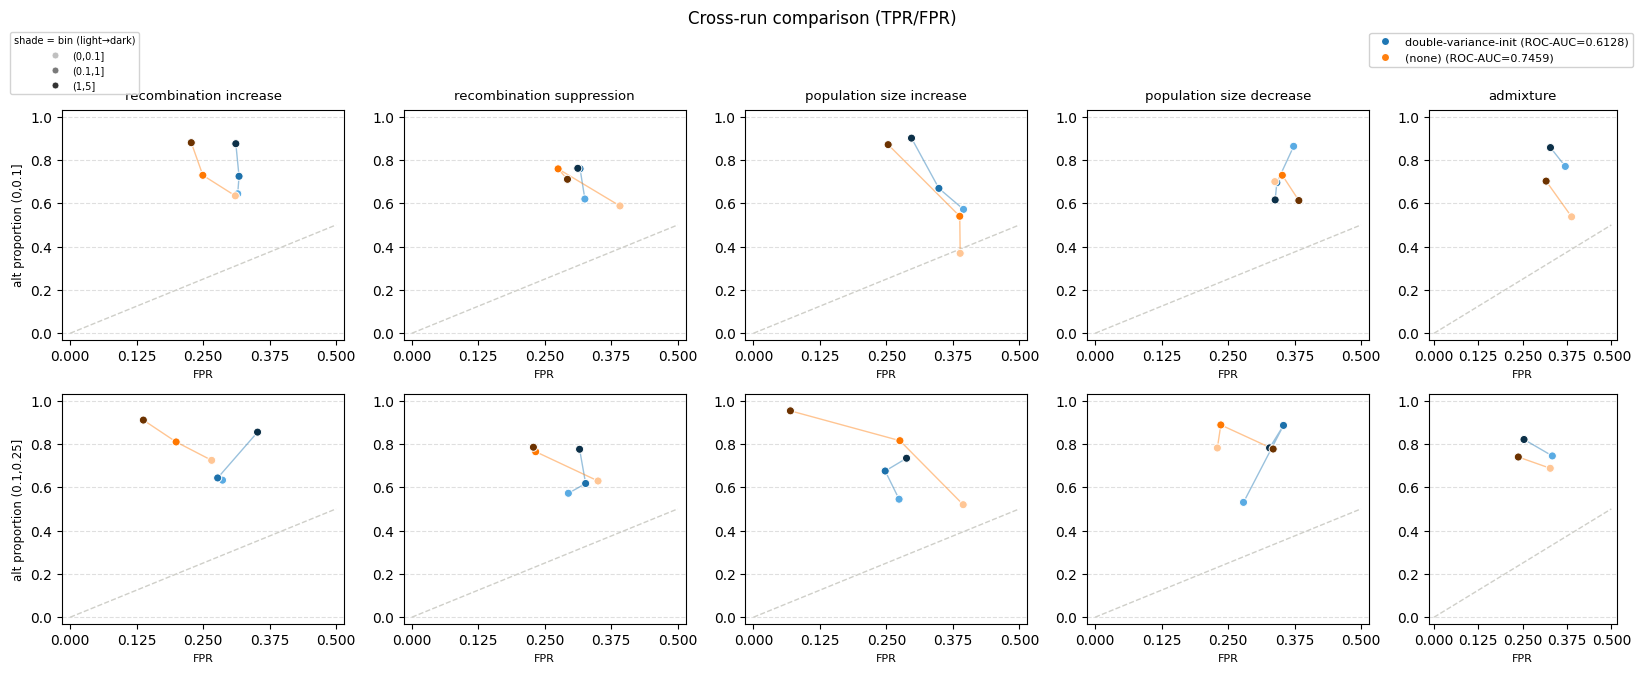

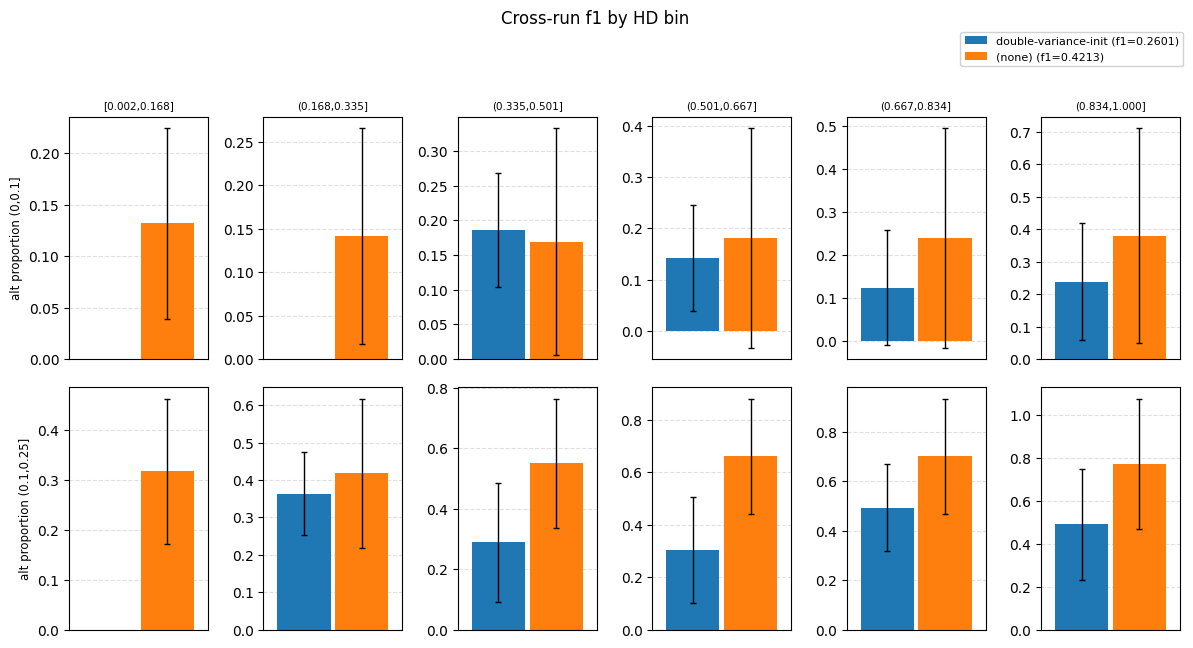

In [57]:
configs_dvi = cra.resolve_configs_cartesian(
    {"--double-variance-init": True, "-d": "gaussian", "--lam": [0.0, 1.0, 1.5]},
    exclude_keywords=["gd", "tau", "boost", "diag", "shift"], agg=["--double-variance-init"],# "fraction_bin", "hd_bin"],
)
cra.plot_stat(configs_dvi, metrics=["f1", "tpr_fpr"], grid_by="hd_bin")
cra.print_configs(configs_dvi)

[<Figure size 1400x400 with 5 Axes>]

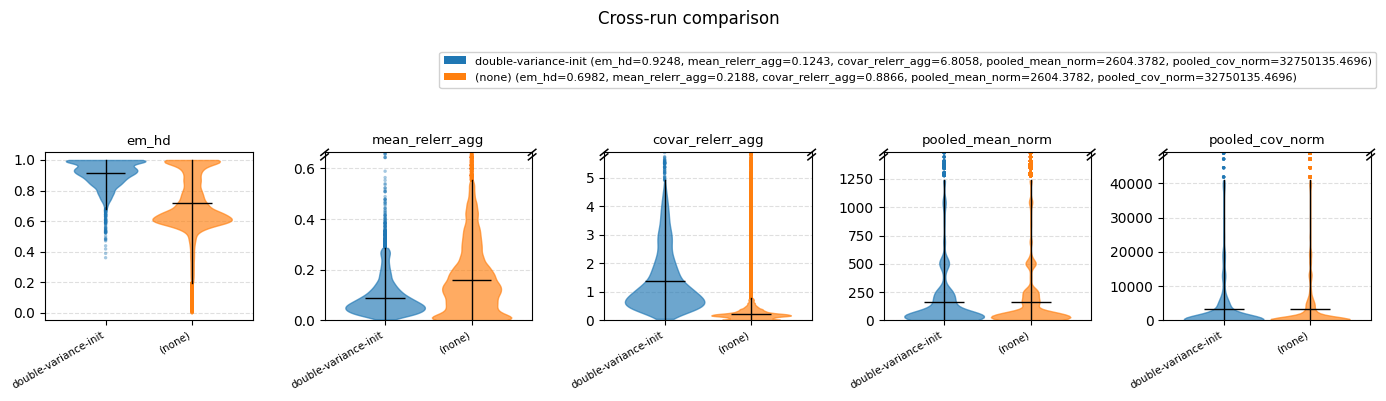

In [58]:

cra.plot_stat(configs_dvi, metrics=["em_hd", "mean_relerr_agg", "covar_relerr_agg", "pooled_mean_norm",  "pooled_cov_norm"], plot_type='violin')

### double-variance-init x repulsion/annealing

[skip] no matching run dirs for config 'double-variance-init (none) annealing'
[skip] no matching run dirs for config '(none) (none) annealing'
double-variance-init repulsion annealing (3 runs, mean_relerr_agg=0.1338, covar_relerr_agg=10.2105, em_hd=0.9405):
  step size: 1k,800k,1m
  store/phlag/gaussian/w1m_s1k/var2x/repulsion/annealing/lam1.5
  store/phlag/gaussian/w1m_s1m/var2x/repulsion/annealing/lam1.5
  store/phlag/gaussian/w1m_s800k/var2x/repulsion/annealing/lam1.5
double-variance-init repulsion (none) (3 runs, mean_relerr_agg=0.1346, covar_relerr_agg=7.5240, em_hd=0.9339):
  step size: 1k,800k,1m
  store/phlag/gaussian/w1m_s1k/var2x/repulsion
  store/phlag/gaussian/w1m_s1m/var2x/repulsion
  store/phlag/gaussian/w1m_s800k/var2x/repulsion
double-variance-init (none) (none) (3 runs, mean_relerr_agg=0.0993, covar_relerr_agg=1.6112, em_hd=0.8837):
  step size: 1k,800k,1m
  store/phlag/gaussian/w1m_s1k/var2x
  store/phlag/gaussian/w1m_s1m/var2x
  store/phlag/gaussian/w1m_s800k/var2x


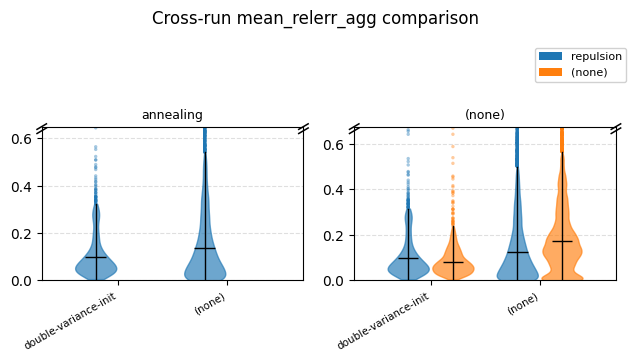

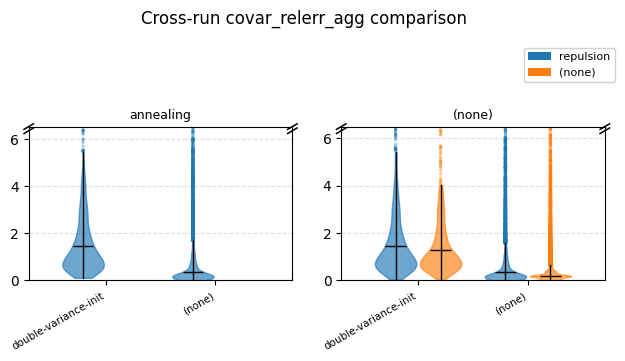

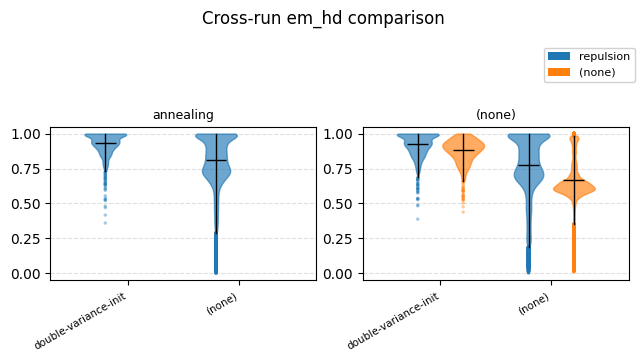

In [59]:
configs_dvi_ra = cra.resolve_configs_cartesian(
    {"--double-variance-init": True, "--ap": "repulsion", "--annealing": True},
    exclude_keywords=["gd", "tau", "boost", "diag", "shift"],
    agg=["--double-variance-init", "--ap", "--annealing"],
)
cra.plot_stat(configs_dvi_ra, metrics=["mean_relerr_agg", "covar_relerr_agg", "em_hd"], plot_type="violin")
cra.print_configs(configs_dvi_ra, paths=True)

### heatmap: HD vs alt proportion, dvi on/off

In [ ]:
# cra.plot_stat(configs_dvi, metrics=["em_hd"], grid_by="--double-variance-init", plot_type="heatmap")

AssertionError: 

### heatmap: HD vs alt proportion, dvi x repulsion x annealing

In [ ]:
# cra.plot_stat(configs_dvi_ra, metrics=["em_hd"], grid_by="hd_bin", plot_type="heatmap")

ValueError: could not convert string to float: '(none)'

### Aggregating by window/step size

s = w

(0,0.1] 10000 10000 10X down (0,0.1] (3 runs, em_hd=0.5120, transition_null_to_alt=0.1559, transition_alt_to_null=0.3745, alt_prop_pred=0.0567):
  alt emission parameterization: free,repulsion
  lambda: 1.0,1.5
  annealing
  store/phlag/gaussian/w10k_s10k
  store/phlag/gaussian/w10k_s10k/repulsion
  store/phlag/gaussian/w10k_s10k/repulsion/annealing/lam1.5
(0,0.1] 10000 10000 10X down (0.1,0.25] (3 runs, em_hd=0.4977, transition_null_to_alt=0.1155, transition_alt_to_null=0.2422, alt_prop_pred=0.2000):
  alt emission parameterization: free,repulsion
  lambda: 1.0,1.5
  annealing
  store/phlag/gaussian/w10k_s10k
  store/phlag/gaussian/w10k_s10k/repulsion
  store/phlag/gaussian/w10k_s10k/repulsion/annealing/lam1.5
(0,0.1] 10000 10000 10X up (0,0.1] (3 runs, em_hd=0.5231, transition_null_to_alt=0.2520, transition_alt_to_null=0.4397, alt_prop_pred=0.0567):
  alt emission parameterization: free,repulsion
  lambda: 1.0,1.5
  annealing
  store/phlag/gaussian/w10k_s10k
  store/phlag/gaussian/w1

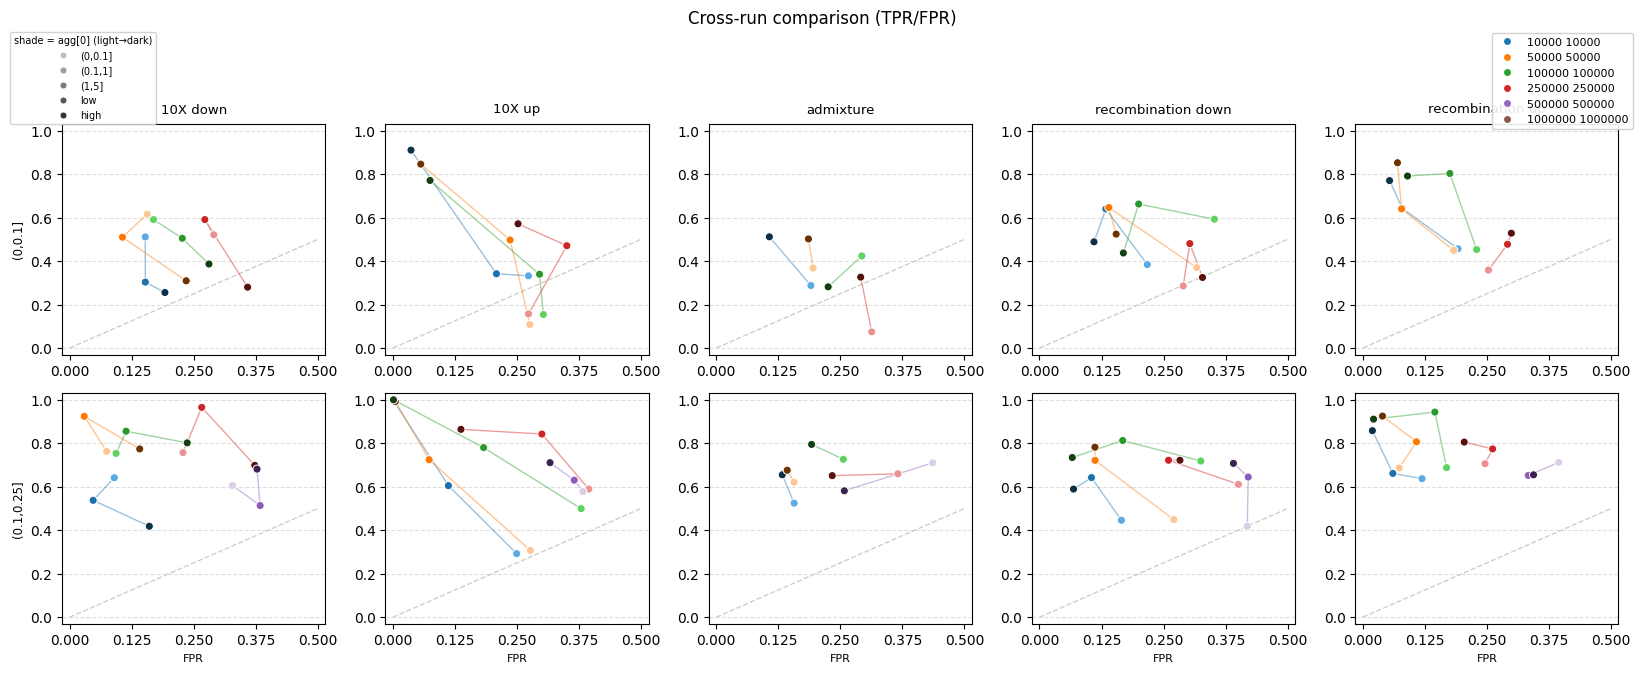

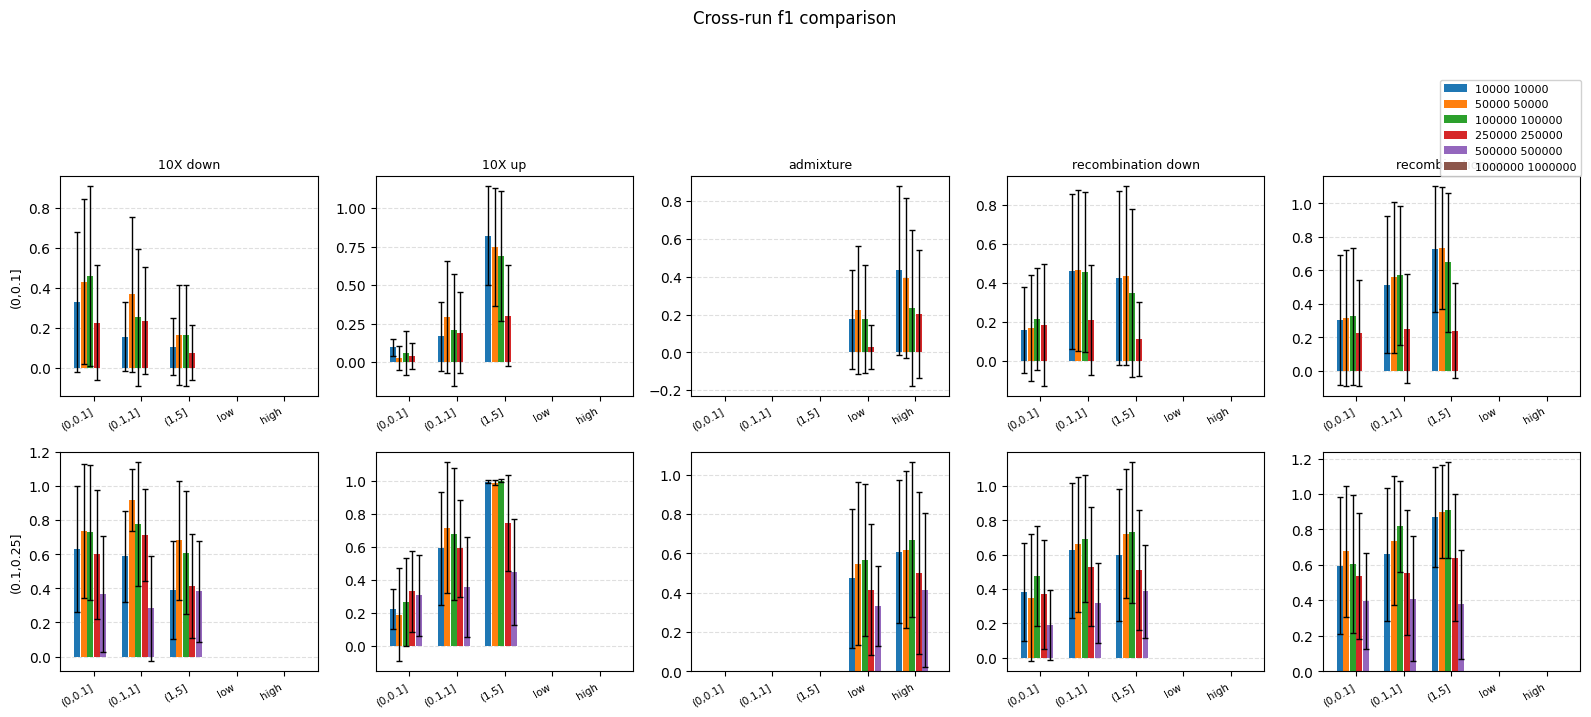

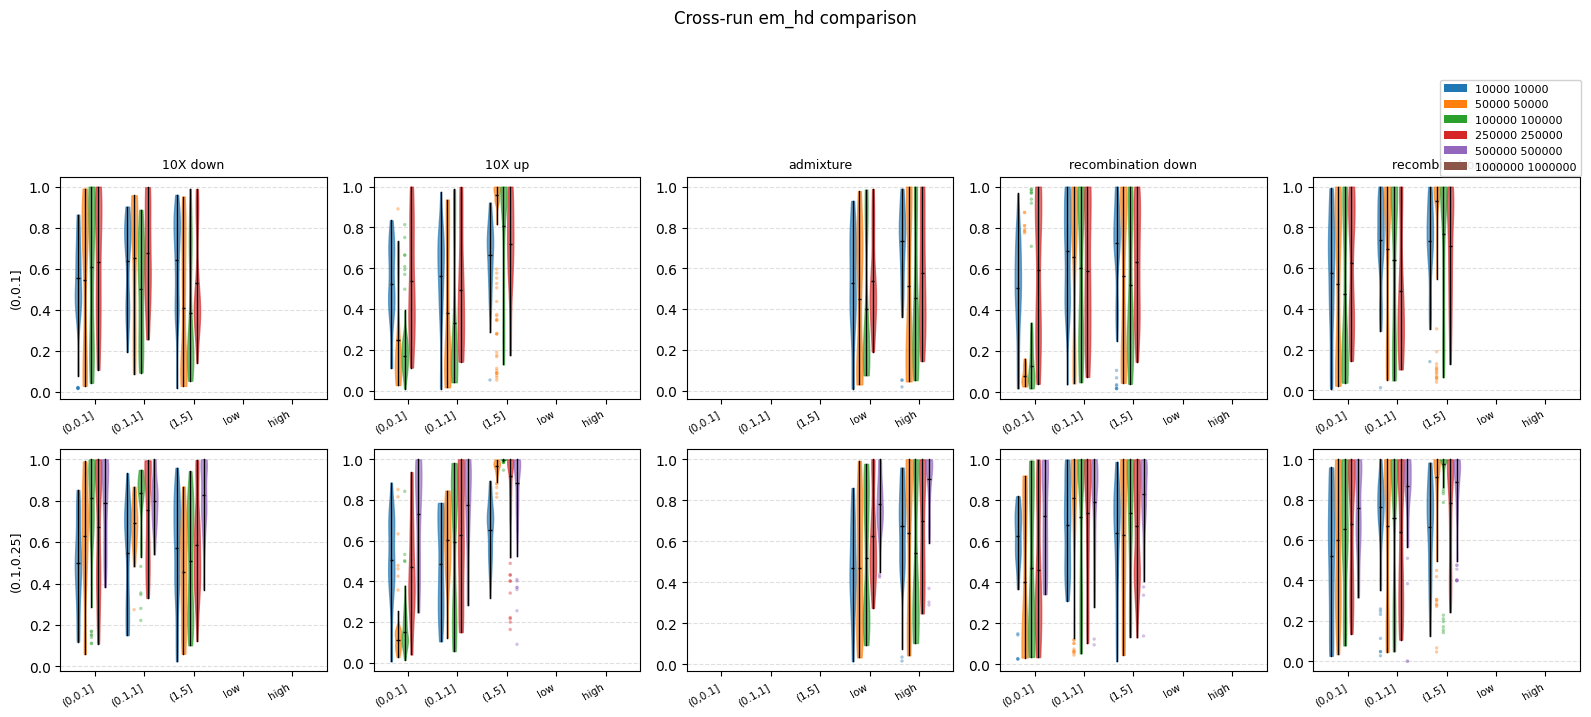

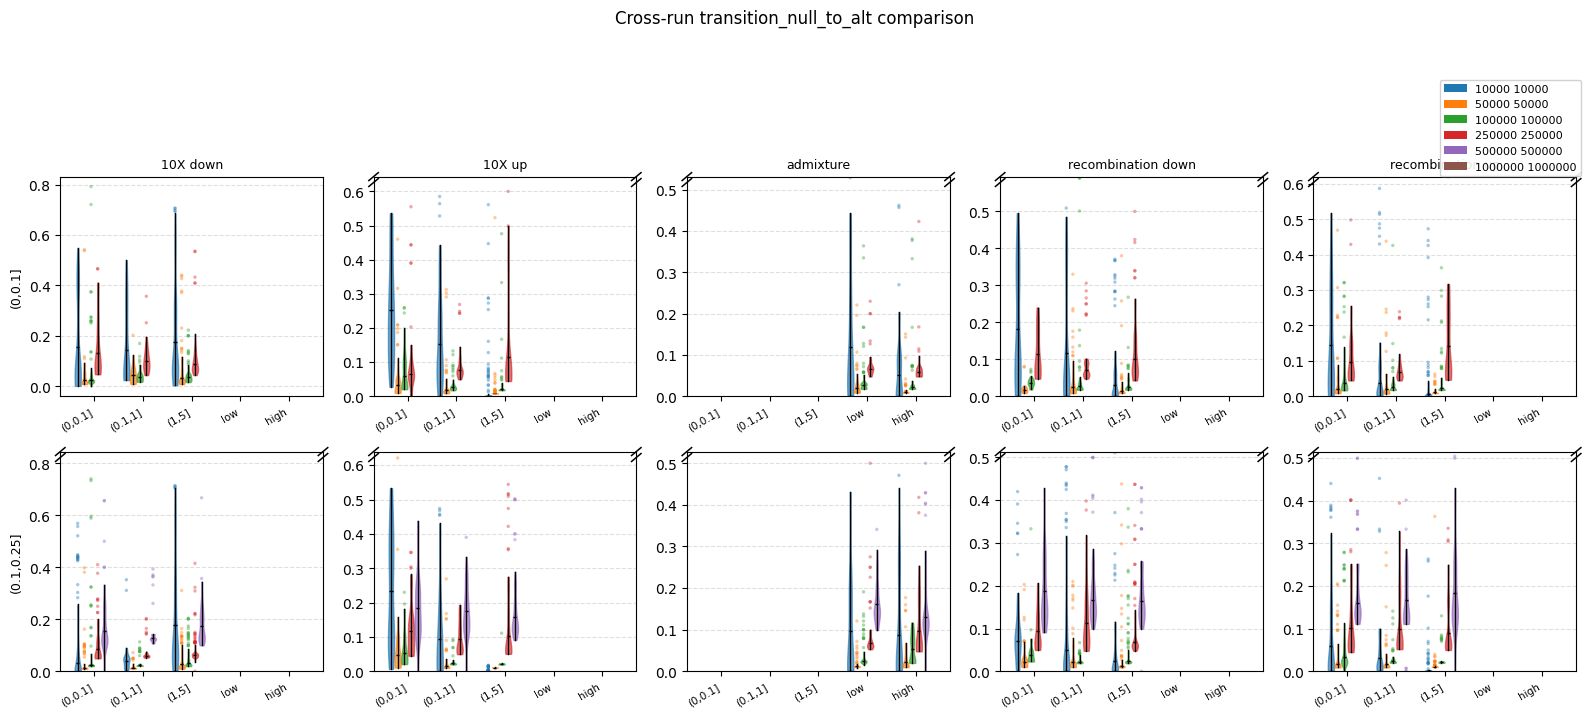

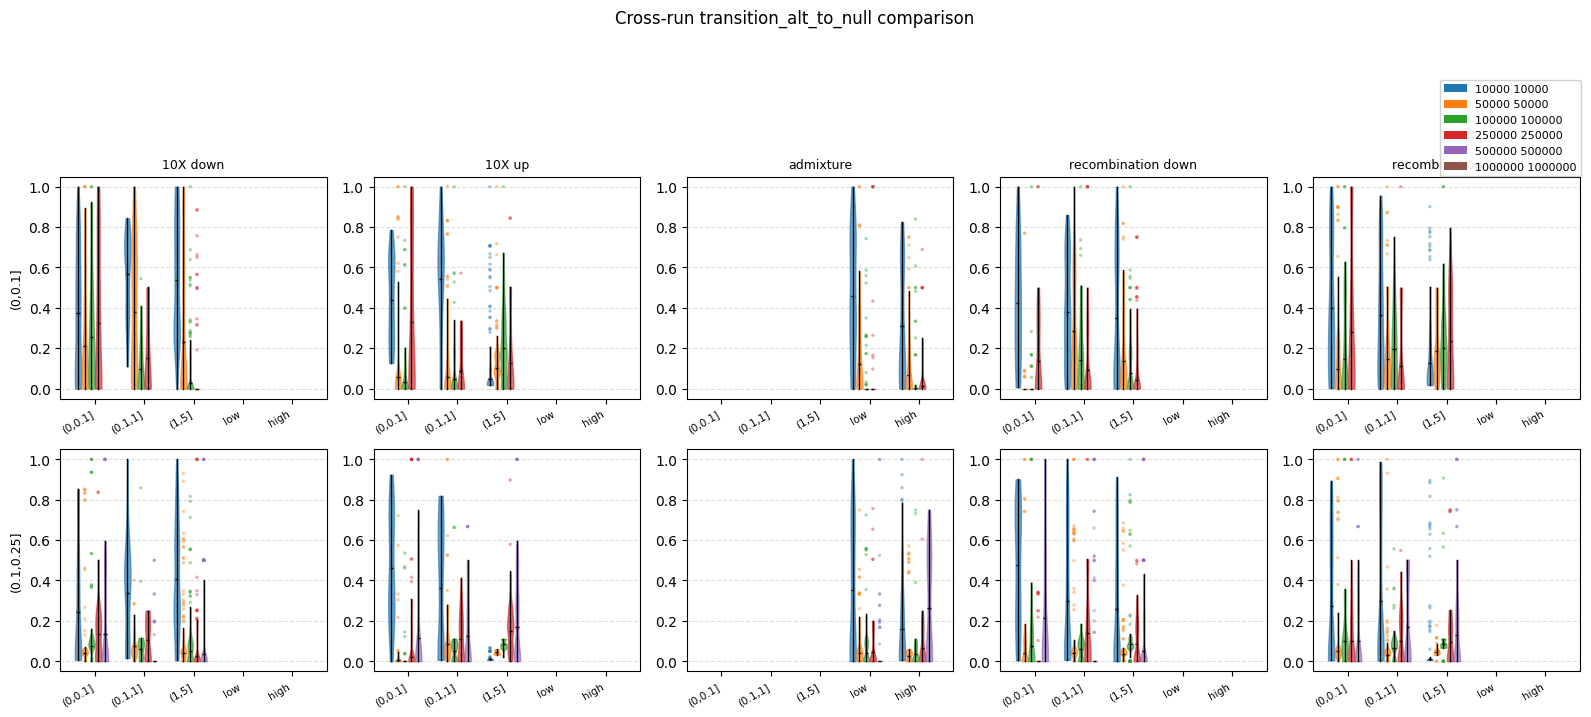

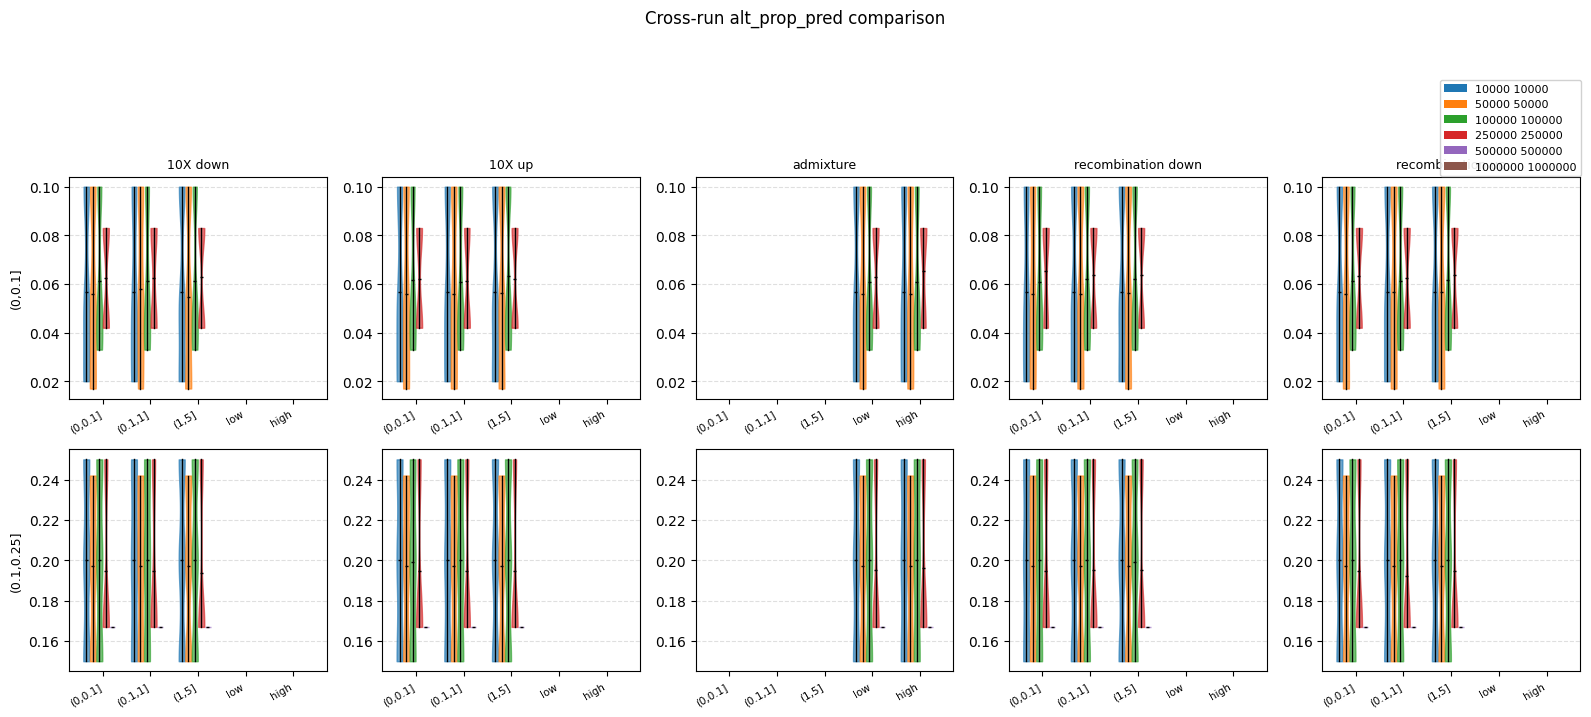

In [61]:
configs_ws = cra.resolve_configs_cartesian(
    {"-s": ["1.0"]},
    agg=["x_bin", "-w", "merged_category", "fraction_bin"],
    exclude_keywords=("tau", "boost", "gd", "diag")
)
cra.plot_stat(configs_ws, metrics=["f1", "tpr_fpr"])
cra.plot_stat(
    configs_ws,
    metrics=["em_hd", "transition_null_to_alt", "transition_alt_to_null", "alt_prop_pred"],
    plot_type="violin",
)
cra.print_configs(configs_ws, paths=True)

s = 0.8w

[skip] no matching run dirs for config '(0,0.1] 10000 8000 10X down (0,0.1]'
[skip] no matching run dirs for config '(0,0.1] 10000 8000 10X down (0.1,0.25]'
[skip] no matching run dirs for config '(0,0.1] 10000 8000 10X up (0,0.1]'
[skip] no matching run dirs for config '(0,0.1] 10000 8000 10X up (0.1,0.25]'
[skip] no matching run dirs for config '(0,0.1] 10000 8000 admixture (0,0.1]'
[skip] no matching run dirs for config '(0,0.1] 10000 8000 admixture (0.1,0.25]'
[skip] no matching run dirs for config '(0,0.1] 10000 8000 recombination down (0,0.1]'
[skip] no matching run dirs for config '(0,0.1] 10000 8000 recombination down (0.1,0.25]'
[skip] no matching run dirs for config '(0,0.1] 10000 8000 recombination up (0,0.1]'
[skip] no matching run dirs for config '(0,0.1] 10000 8000 recombination up (0.1,0.25]'
[skip] no matching run dirs for config '(0.1,1] 10000 8000 10X down (0,0.1]'
[skip] no matching run dirs for config '(0.1,1] 10000 8000 10X down (0.1,0.25]'
[skip] no matching run d

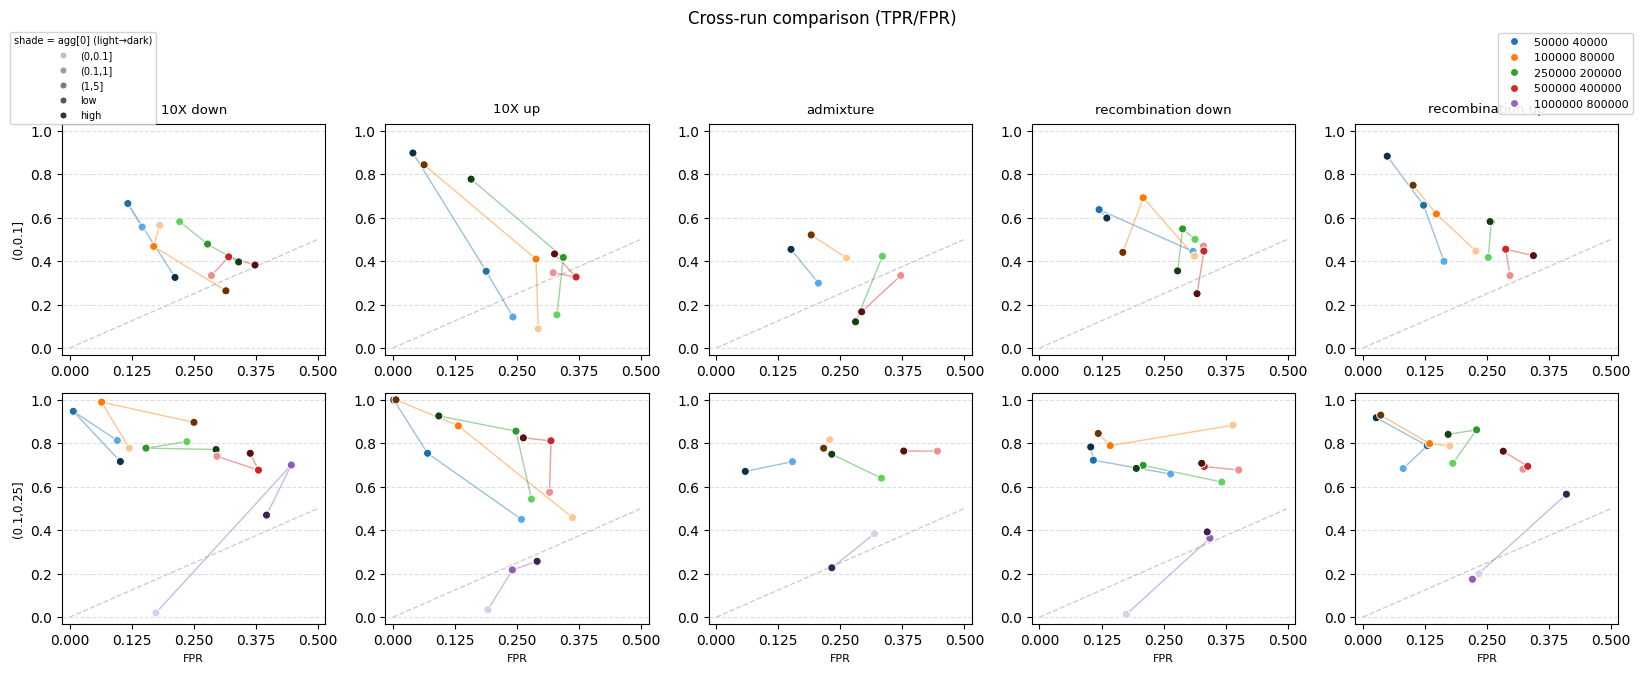

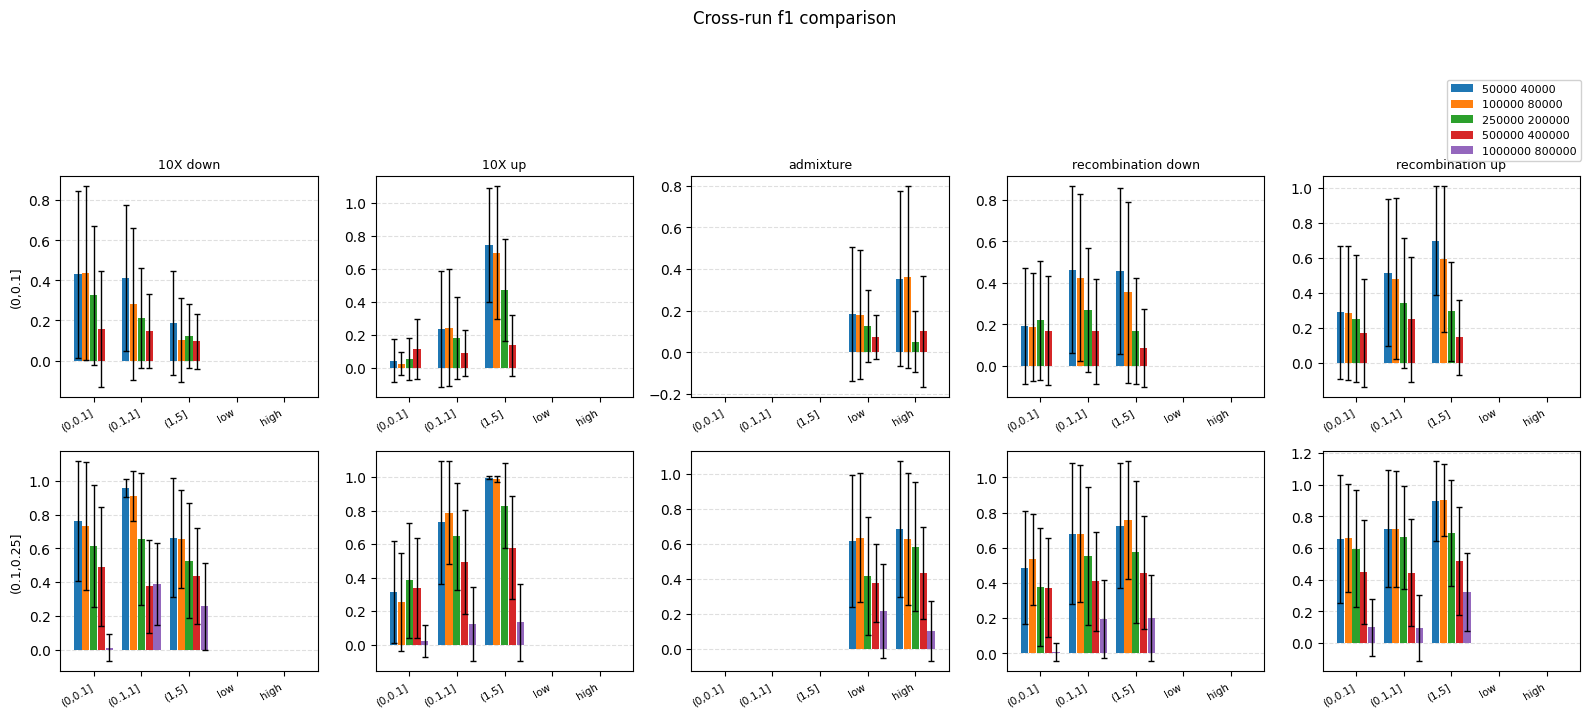

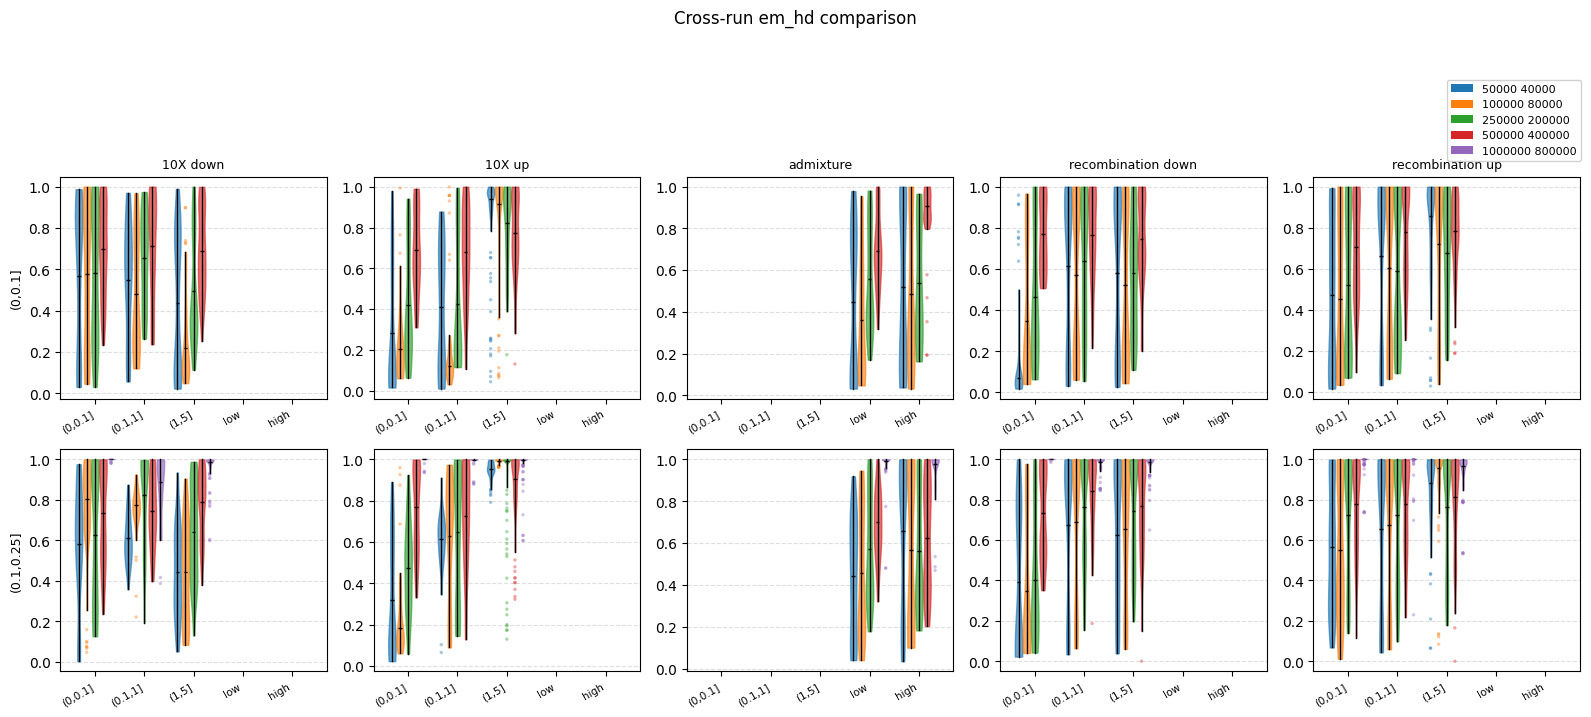

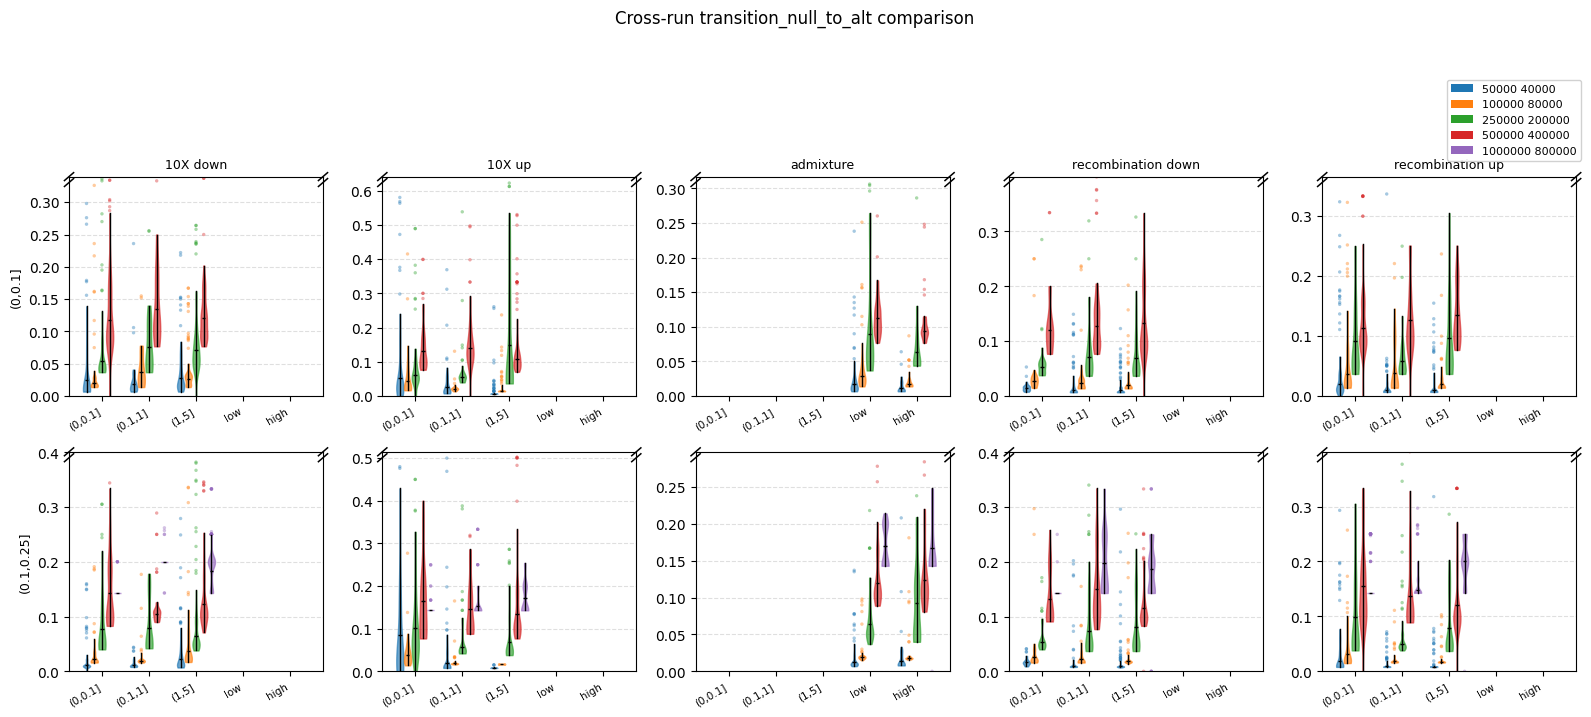

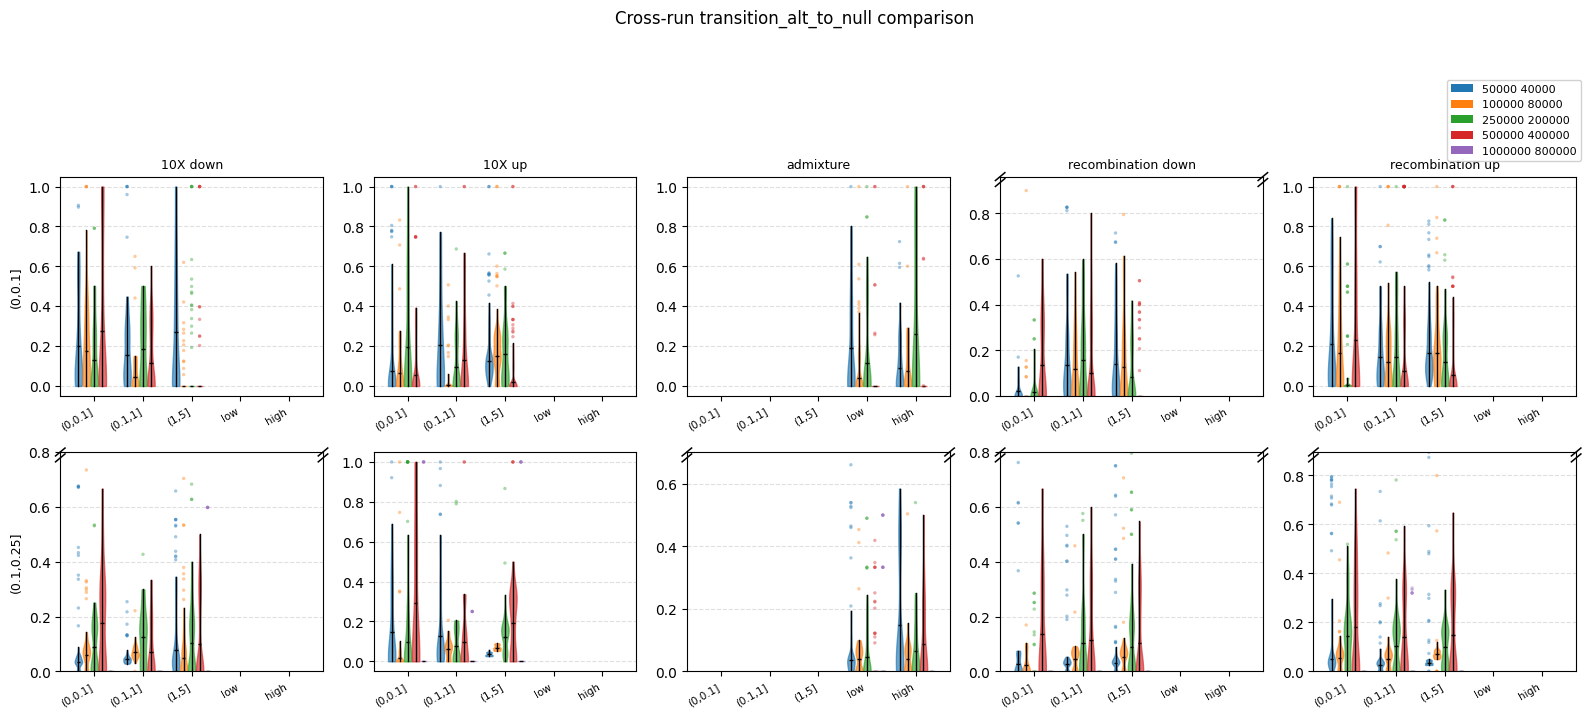

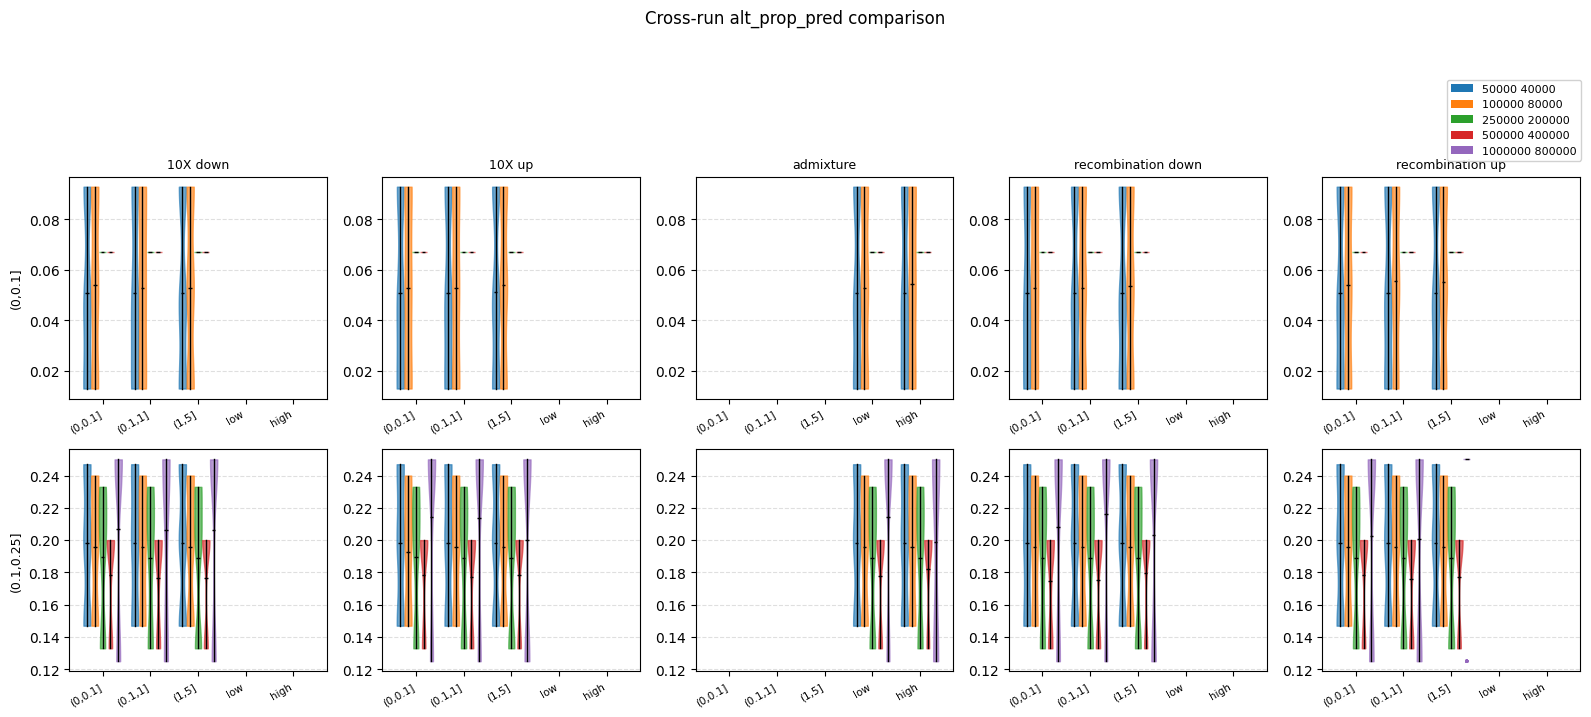

In [62]:
configs_ws = cra.resolve_configs_cartesian(
    {"-s": ["0.8"]},
    agg=["x_bin", "-w", "merged_category", "fraction_bin"],
    exclude_keywords=("tau", "boost", "gd", "diag")
)
cra.plot_stat(configs_ws, metrics=["f1", "tpr_fpr"])
cra.plot_stat(
    configs_ws,
    metrics=["em_hd", "transition_null_to_alt", "transition_alt_to_null", "alt_prop_pred"],
    plot_type="violin",
)
cra.print_configs(configs_ws, paths=True)

[skip] no matching run dirs for config '10000 40000'
[skip] no matching run dirs for config '10000 50000'
[skip] no matching run dirs for config '10000 80000'
[skip] no matching run dirs for config '10000 100000'
[skip] no matching run dirs for config '10000 200000'
[skip] no matching run dirs for config '10000 250000'
[skip] no matching run dirs for config '10000 400000'
[skip] no matching run dirs for config '10000 500000'
[skip] no matching run dirs for config '10000 800000'
[skip] no matching run dirs for config '10000 1000000'
[skip] no matching run dirs for config '50000 10000'
[skip] no matching run dirs for config '50000 80000'
[skip] no matching run dirs for config '50000 100000'
[skip] no matching run dirs for config '50000 200000'
[skip] no matching run dirs for config '50000 250000'
[skip] no matching run dirs for config '50000 400000'
[skip] no matching run dirs for config '50000 500000'
[skip] no matching run dirs for config '50000 800000'
[skip] no matching run dirs for 

10000 1000 (3 runs, f1=0.3394, roc_auc=0.6630, em_hd=0.6784, transition_null_to_alt=0.0304, transition_alt_to_null=0.0518, alt_prop_pred=0.1283, pooled_mean_norm=2604.3782, pooled_cov_norm=32750135.4696):
  alt emission parameterization: free,repulsion
  lambda: 1.0,1.5
  annealing
  store/phlag/gaussian/w10k_s1k
  store/phlag/gaussian/w10k_s1k/repulsion
  store/phlag/gaussian/w10k_s1k/repulsion/annealing/lam1.5
10000 10000 (3 runs, f1=0.4975, roc_auc=0.7515, em_hd=0.6109, transition_null_to_alt=0.1091, transition_alt_to_null=0.3256, alt_prop_pred=0.1283, pooled_mean_norm=2604.3782, pooled_cov_norm=32750135.4696):
  alt emission parameterization: free,repulsion
  lambda: 1.0,1.5
  annealing
  store/phlag/gaussian/w10k_s10k
  store/phlag/gaussian/w10k_s10k/repulsion
  store/phlag/gaussian/w10k_s10k/repulsion/annealing/lam1.5
50000 1000 (45 runs, f1=0.4285, roc_auc=0.7898, em_hd=0.6835, transition_null_to_alt=0.0096, transition_alt_to_null=0.0114, alt_prop_pred=0.1283, pooled_mean_norm=2

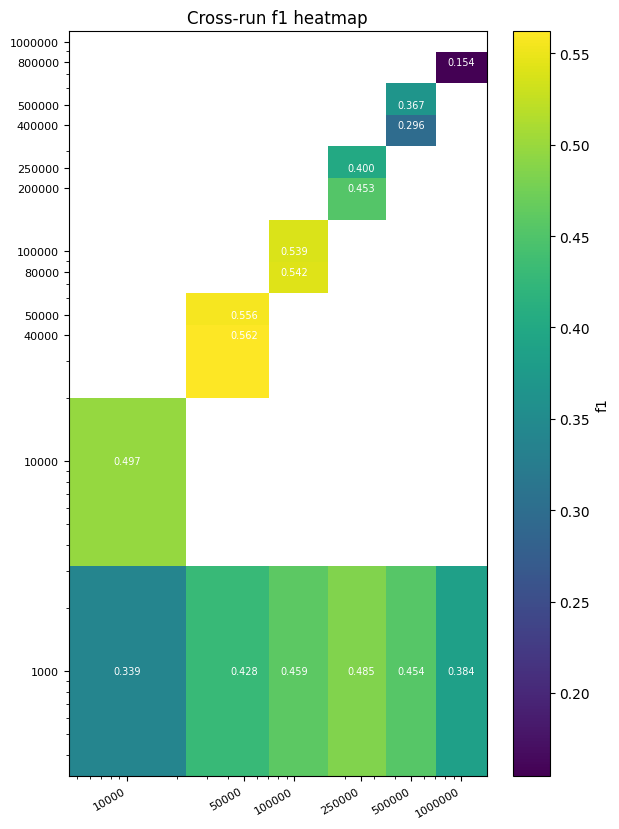

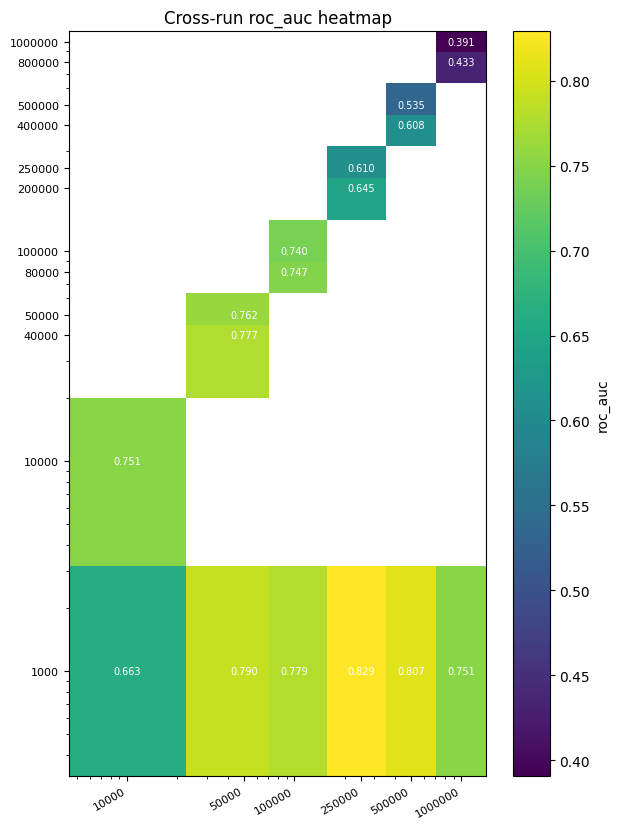

In [63]:
configs_ws = cra.resolve_configs_cartesian(
    { },
    agg=["-w", "-s"],
    exclude_keywords=("tau", "boost", "gd", "diag", "shift"),
)

cra.plot_stat(configs_ws, metrics=["f1"], plot_type="heatmap")
cra.plot_stat(configs_ws, metrics=["roc_auc"], plot_type="heatmap")
cra.print_configs(configs_ws, metrics=["f1", "roc_auc", "em_hd", "transition_null_to_alt", "transition_alt_to_null", "alt_prop_pred", "pooled_mean_norm", "pooled_cov_norm"], paths=True)


s = 1k

(0,0.1] 10000 10X down (0,0.1] (3 runs, em_hd=0.6401, transition_null_to_alt=0.0412, transition_alt_to_null=0.0566, alt_prop_pred=0.0567):
  alt emission parameterization: free,repulsion
  lambda: 1.0,1.5
  annealing
  store/phlag/gaussian/w10k_s1k
  store/phlag/gaussian/w10k_s1k/repulsion
  store/phlag/gaussian/w10k_s1k/repulsion/annealing/lam1.5
(0,0.1] 10000 10X down (0.1,0.25] (3 runs, em_hd=0.6536, transition_null_to_alt=0.0370, transition_alt_to_null=0.0534, alt_prop_pred=0.2000):
  alt emission parameterization: free,repulsion
  lambda: 1.0,1.5
  annealing
  store/phlag/gaussian/w10k_s1k
  store/phlag/gaussian/w10k_s1k/repulsion
  store/phlag/gaussian/w10k_s1k/repulsion/annealing/lam1.5
(0,0.1] 10000 10X up (0,0.1] (3 runs, em_hd=0.6306, transition_null_to_alt=0.0404, transition_alt_to_null=0.0532, alt_prop_pred=0.0567):
  alt emission parameterization: free,repulsion
  lambda: 1.0,1.5
  annealing
  store/phlag/gaussian/w10k_s1k
  store/phlag/gaussian/w10k_s1k/repulsion
  store/

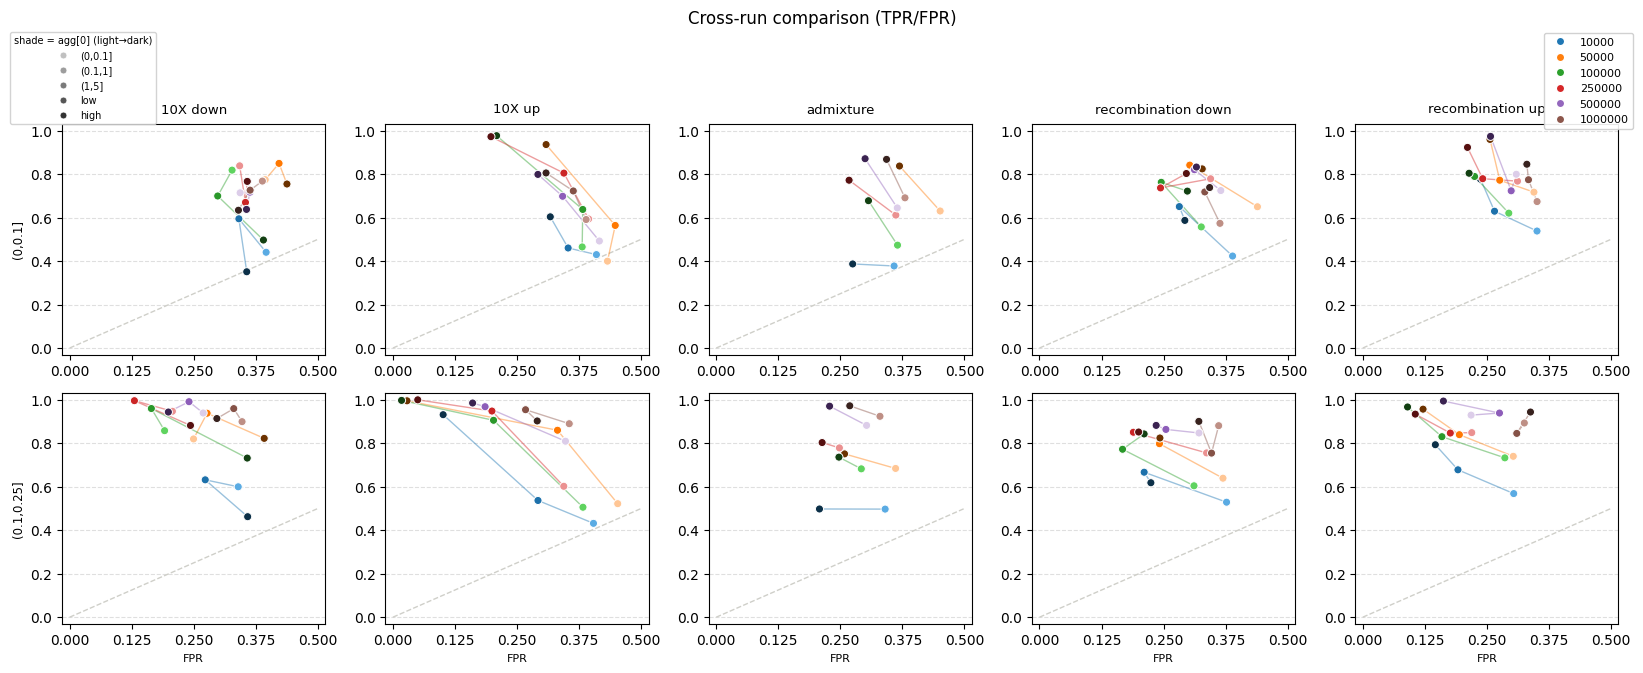

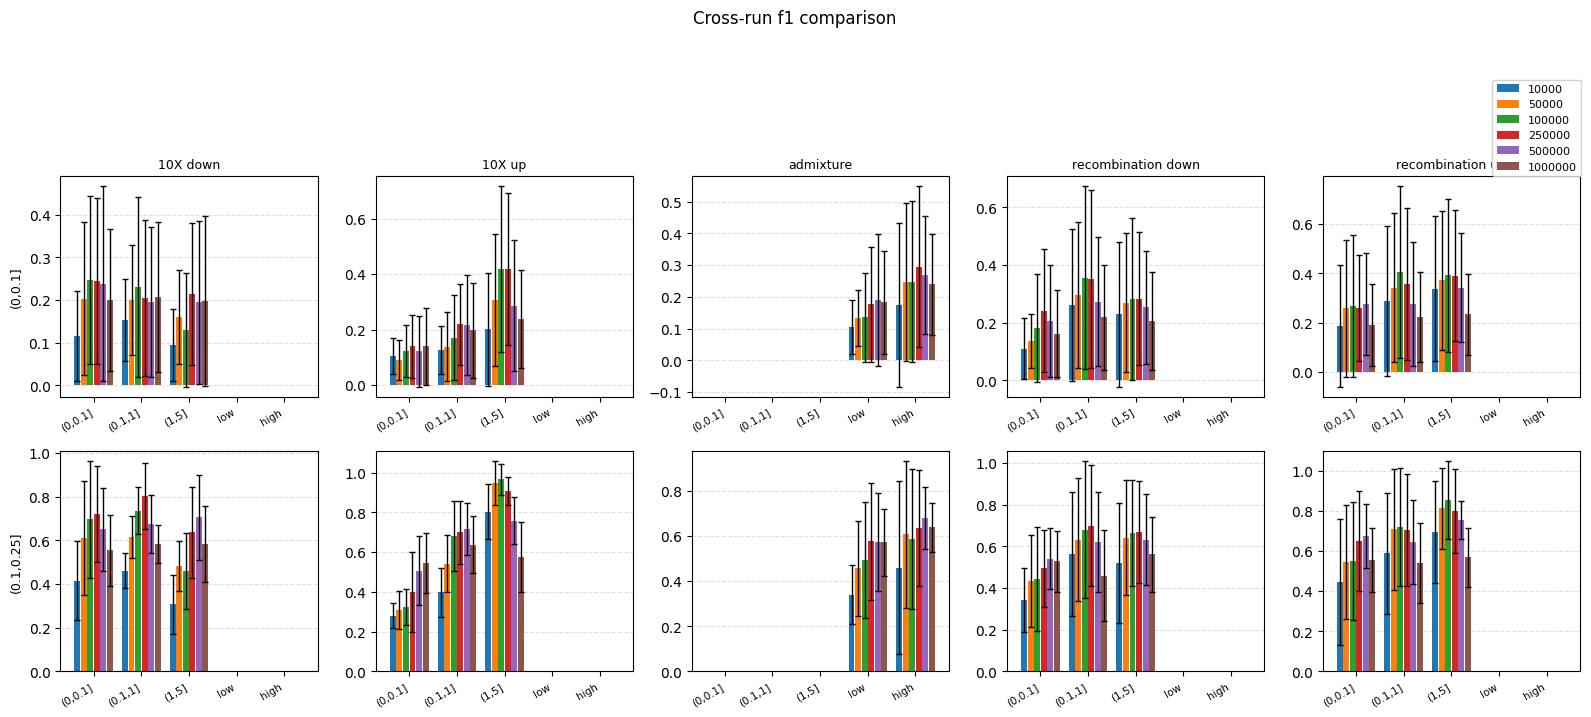

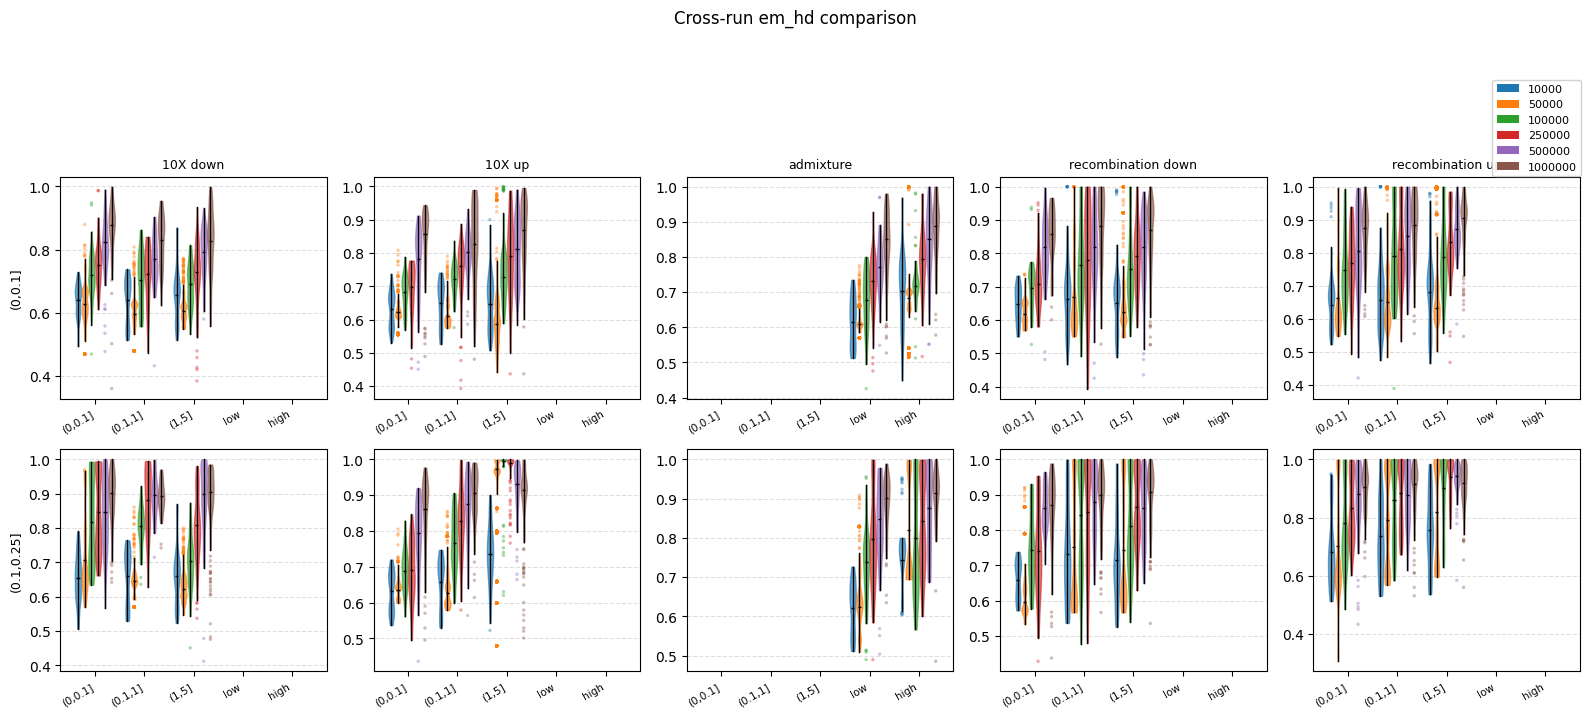

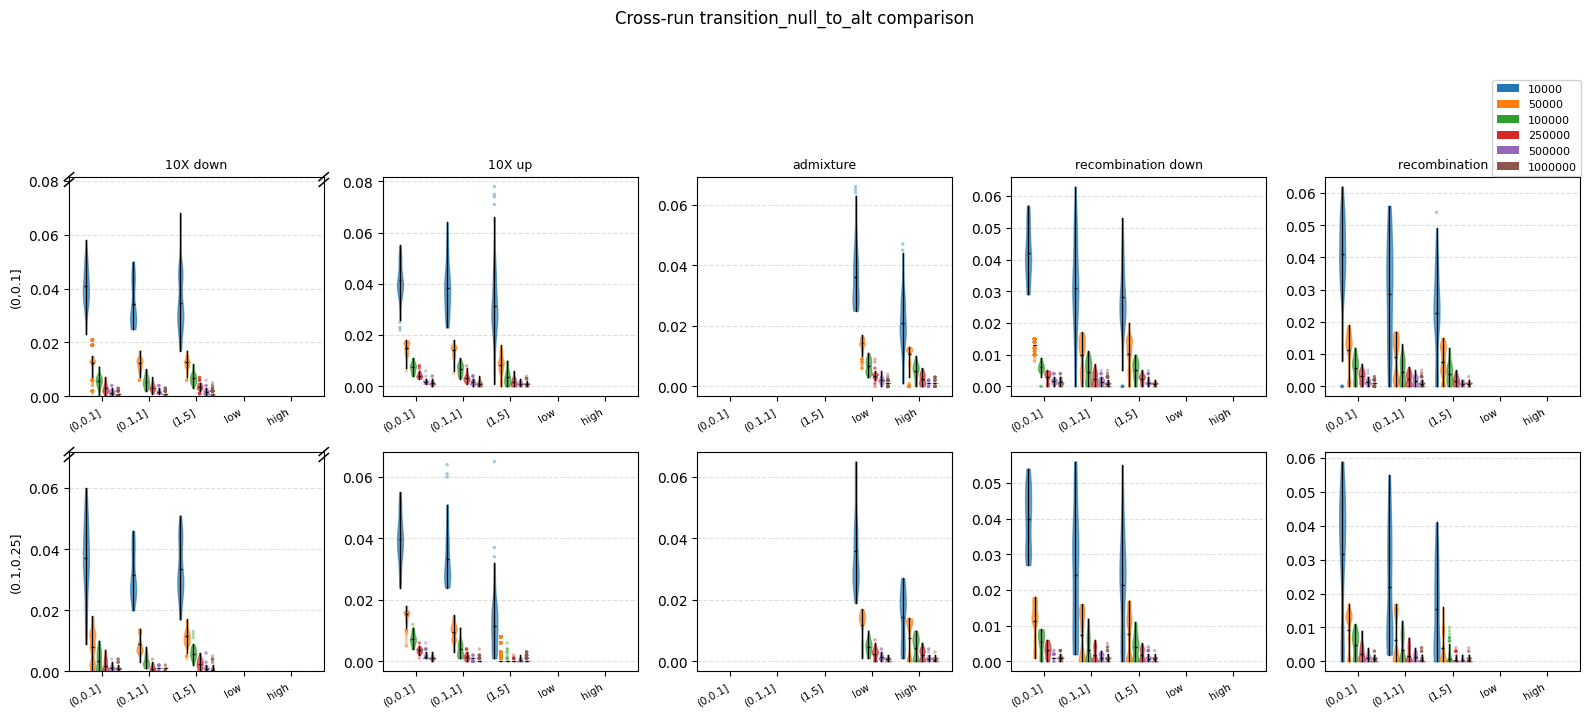

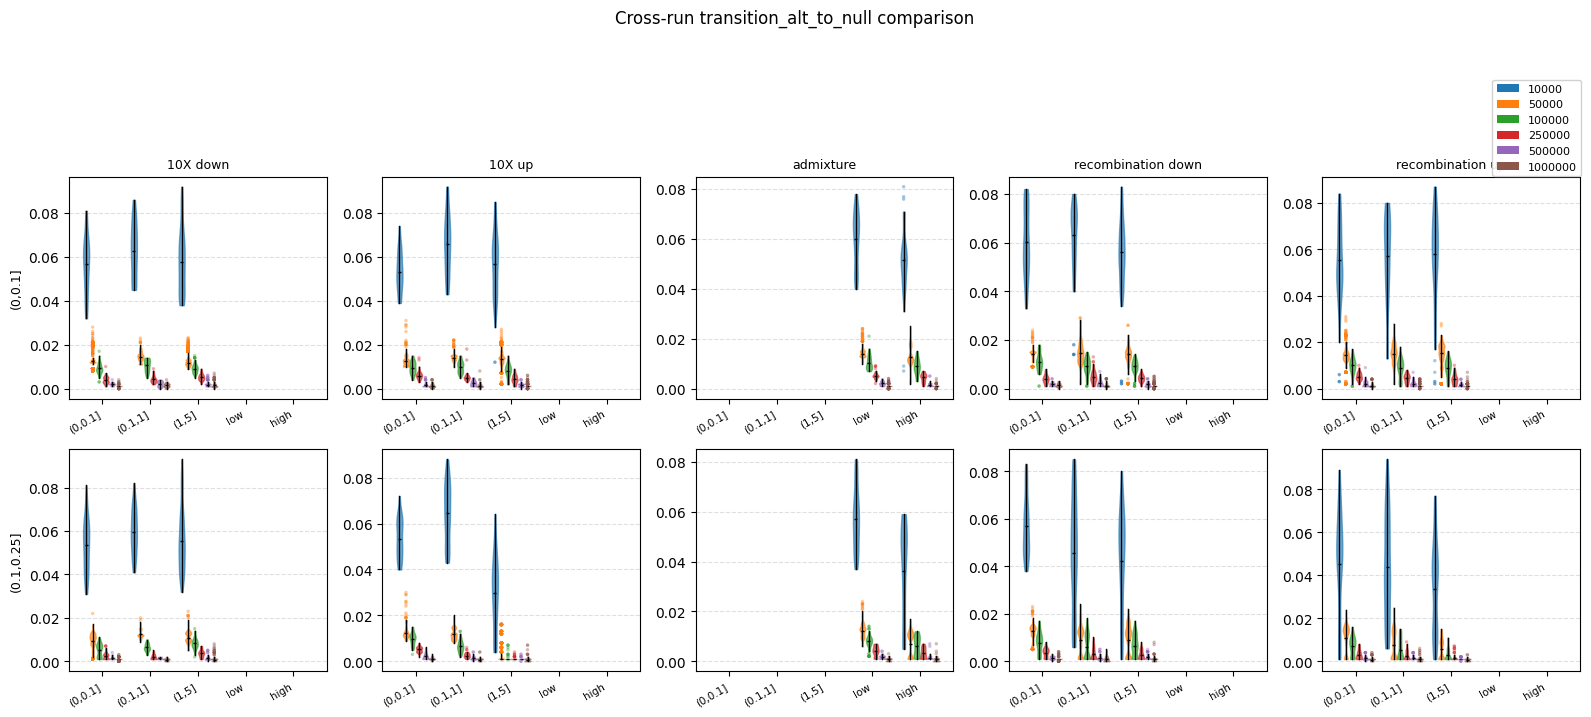

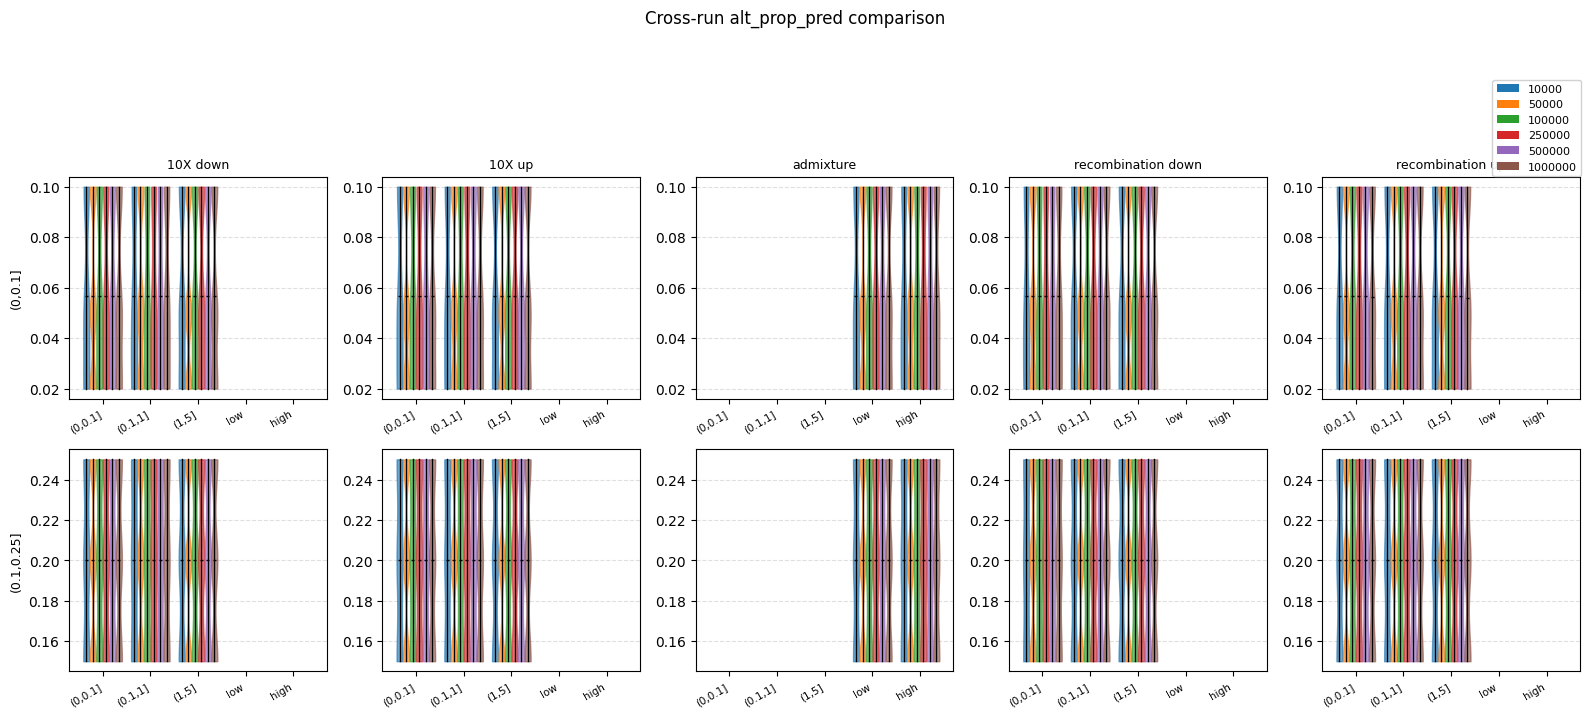

In [64]:
configs_ws = cra.resolve_configs_cartesian(
    {"-s": ["1k"]},
    agg=["x_bin", "-w", "merged_category", "fraction_bin"],
    exclude_keywords=("tau", "boost", "gd", "diag")
)
cra.plot_stat(configs_ws, metrics=["f1", "tpr_fpr"])
cra.plot_stat(
    configs_ws,
    metrics=["em_hd", "transition_null_to_alt", "transition_alt_to_null", "alt_prop_pred"],
    plot_type="violin",
)
cra.print_configs(configs_ws, paths=True)

### Aggregating by repulsion/annealing

Repulsion

(0,0.1] free 10X down (0,0.1] (62 runs, mean_relerr_agg=0.1916, covar_relerr_agg=0.4286, em_hd=0.6179):
  window size: 10k,50k,100k,250k,500k,1m
  step size: 1k,10k,40k,50k,80k,100k,200k,250k,400k,500k,800k,1m
  double-variance-init
  store/phlag/gaussian/w100k_s100k
  store/phlag/gaussian/w100k_s100k/var2x
  store/phlag/gaussian/w100k_s100k/var2x/repulsion
  store/phlag/gaussian/w100k_s100k/var2x/repulsion/annealing/lam1.5
  store/phlag/gaussian/w100k_s1k
  store/phlag/gaussian/w100k_s1k/var2x
  store/phlag/gaussian/w100k_s1k/var2x/repulsion
  store/phlag/gaussian/w100k_s1k/var2x/repulsion/annealing/lam1.5
  store/phlag/gaussian/w100k_s80k
  store/phlag/gaussian/w100k_s80k/var2x
  store/phlag/gaussian/w100k_s80k/var2x/repulsion
  store/phlag/gaussian/w100k_s80k/var2x/repulsion/annealing/lam1.5
  store/phlag/gaussian/w10k_s10k
  store/phlag/gaussian/w10k_s10k/var2x
  store/phlag/gaussian/w10k_s10k/var2x/repulsion
  store/phlag/gaussian/w10k_s10k/var2x/repulsion/annealing/lam1.5
  store

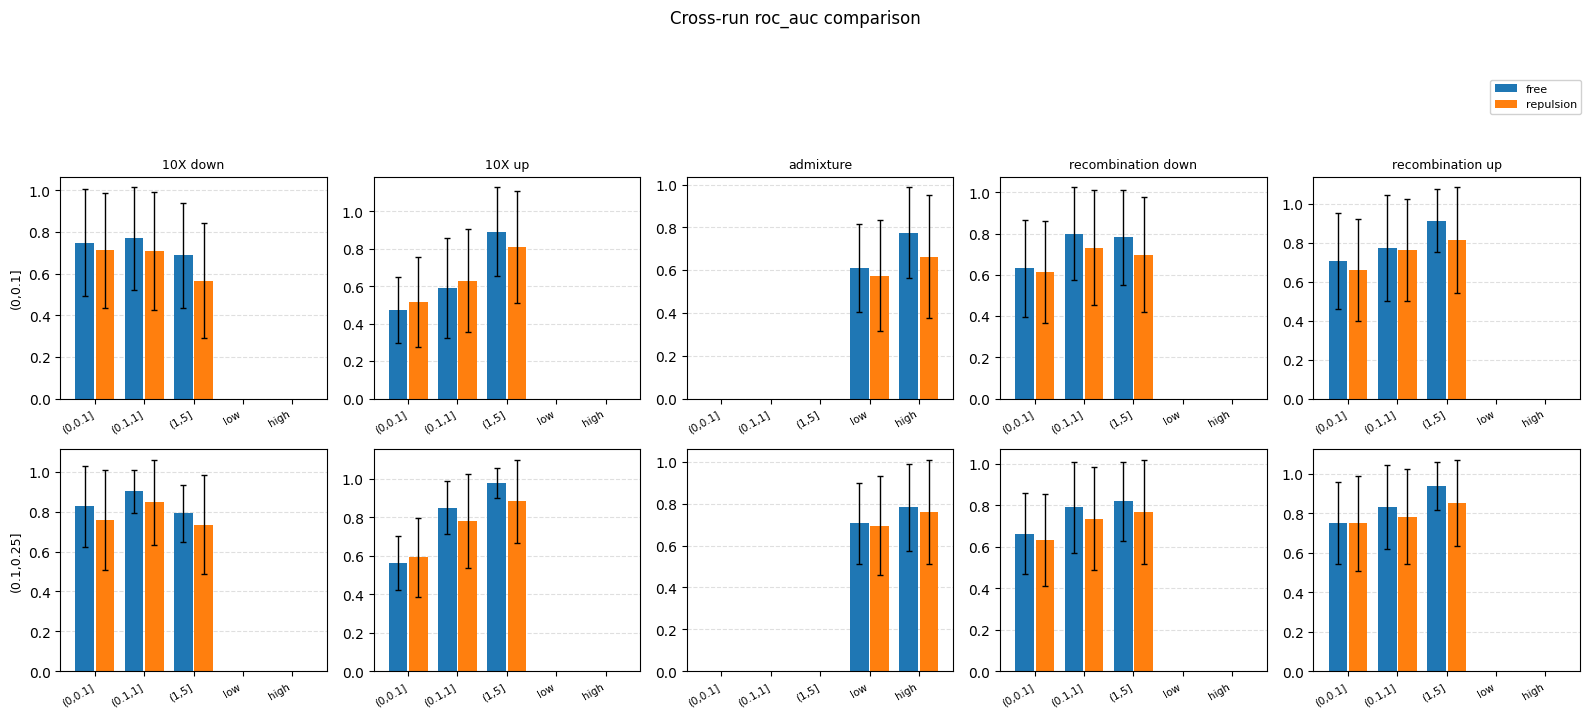

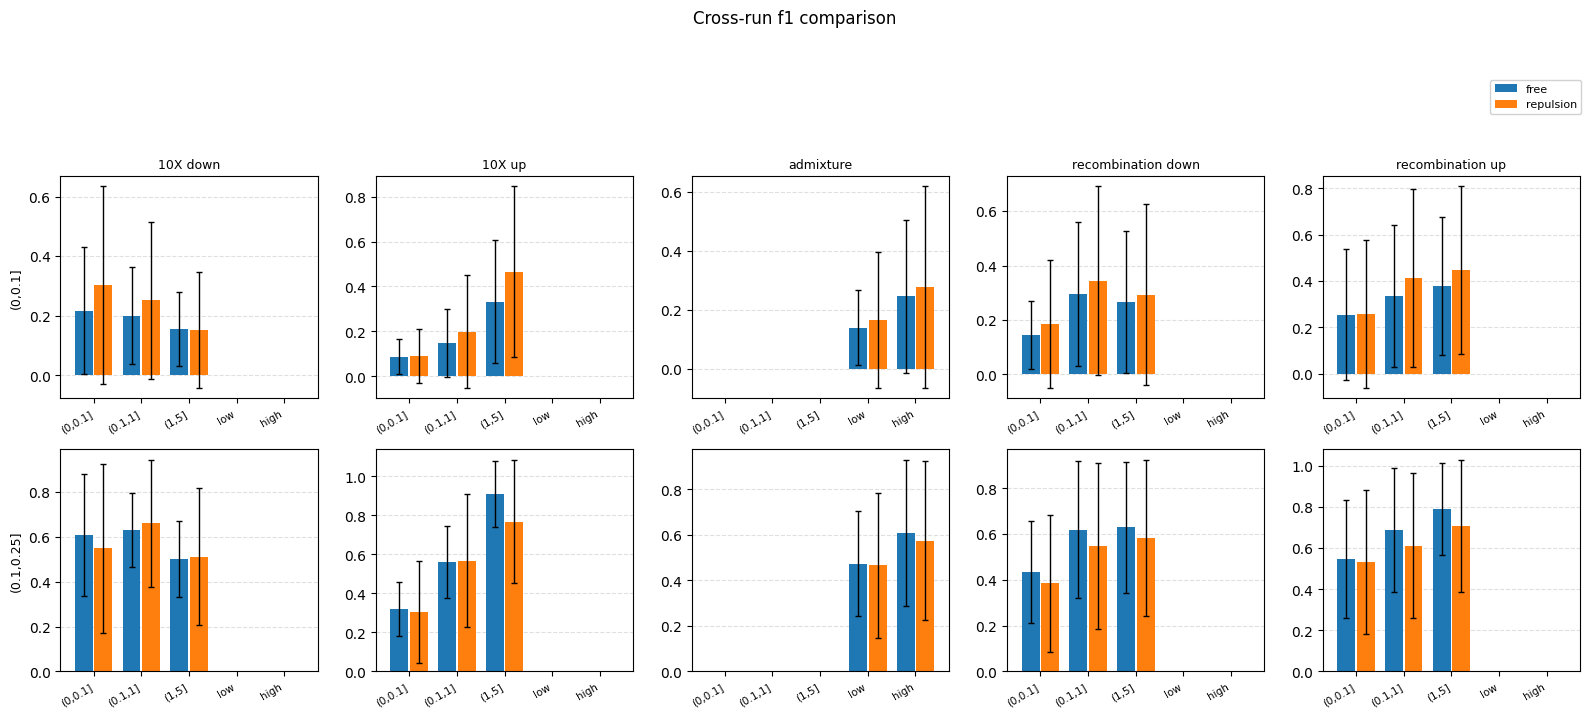

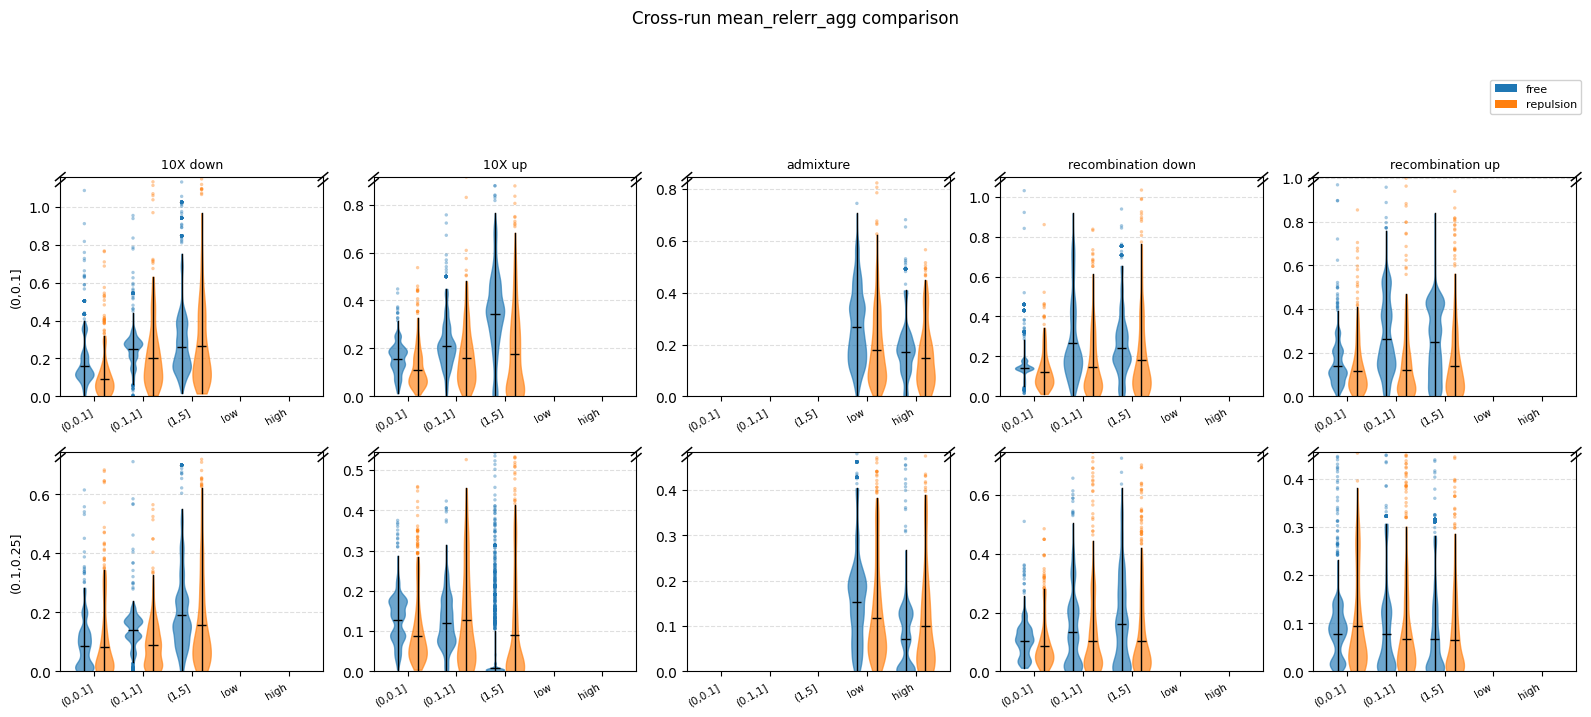

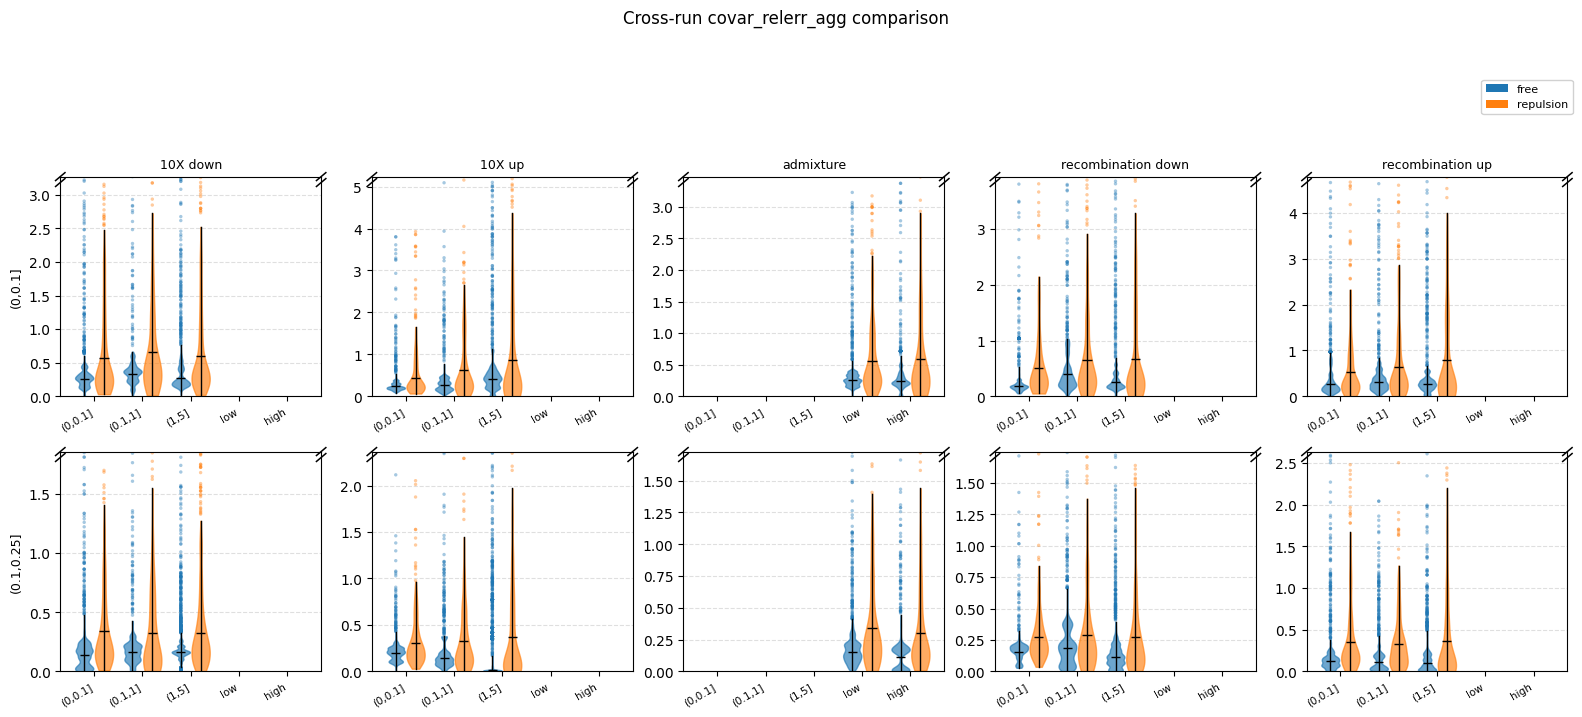

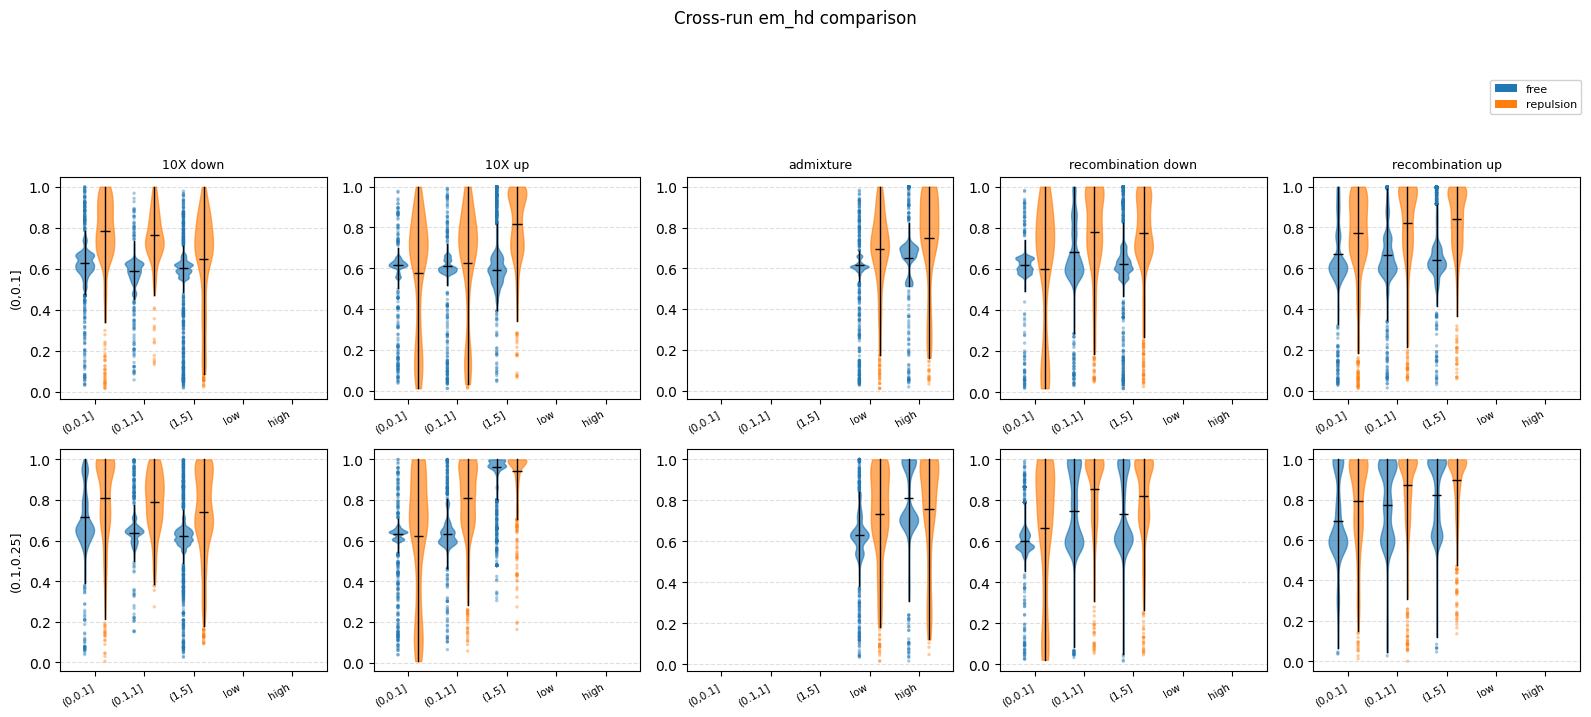

In [65]:
configs_ra = cra.resolve_configs_cartesian(
    {"--annealing": [False]},
    agg=["x_bin", "--ap", "merged_category", "fraction_bin"],
    exclude_keywords=("tau", "boost", "gd", "diag", "shift"),
)
cra.plot_stat(configs_ra, metrics=["roc_auc", "f1"])
cra.plot_stat(configs_ra, metrics=["mean_relerr_agg", "covar_relerr_agg", "em_hd"], plot_type='violin')
cra.print_configs(configs_ra, paths=True)

### repulsion/annealing at fixed w=50k, s=1k

[skip] no matching run dirs for config '(none) annealing'
repulsion annealing (1 runs, roc_auc=0.7532, f1=0.4569, em_hd=0.7885, mean_relerr_agg=0.2358, covar_relerr_agg=0.1908):
  store/phlag/gaussian/w50k_s1k/repulsion/annealing/lam1.5
repulsion (none) (1 runs, roc_auc=0.7668, f1=0.4542, em_hd=0.7673, mean_relerr_agg=0.2344, covar_relerr_agg=0.1958):
  store/phlag/gaussian/w50k_s1k/repulsion
(none) (none) (43 runs, roc_auc=0.7912, f1=0.4272, em_hd=0.6791, mean_relerr_agg=0.2365, covar_relerr_agg=0.2167):
  store/phlag/gaussian/w100k_s100k/var2x
  store/phlag/gaussian/w100k_s100k/var2x/repulsion
  store/phlag/gaussian/w100k_s100k/var2x/repulsion/annealing/lam1.5
  store/phlag/gaussian/w100k_s1k/var2x
  store/phlag/gaussian/w100k_s1k/var2x/repulsion
  store/phlag/gaussian/w100k_s1k/var2x/repulsion/annealing/lam1.5
  store/phlag/gaussian/w100k_s80k/var2x
  store/phlag/gaussian/w100k_s80k/var2x/repulsion
  store/phlag/gaussian/w100k_s80k/var2x/repulsion/annealing/lam1.5
  store/phlag/gaus

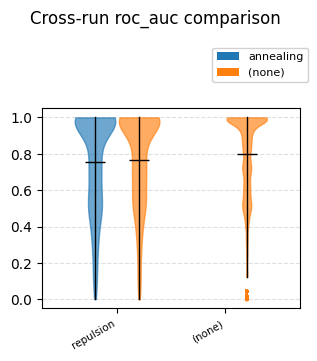

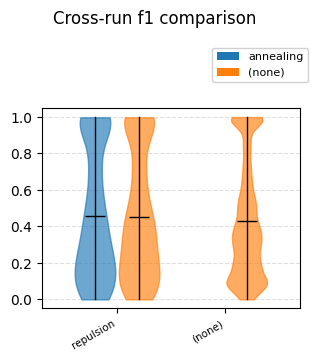

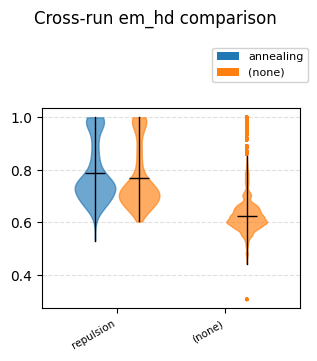

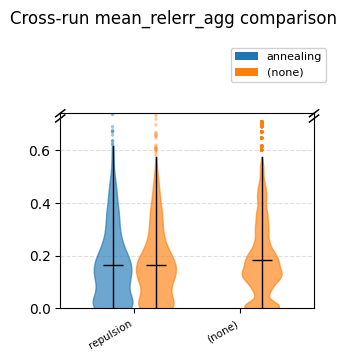

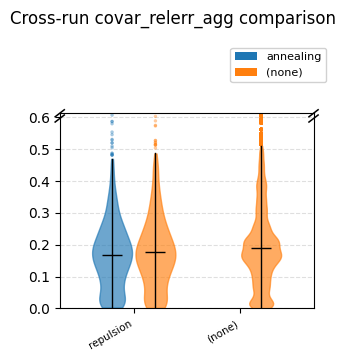

In [66]:
configs_ra_fixed = cra.resolve_configs_cartesian(
    {"-w": ["50k"], "-s": ["1k"], "--ap": "repulsion", "--annealing": True},
    agg=["--ap", "--annealing"],
    exclude_keywords=("tau", "boost", "gd", "diag", "shift"),
)
cra.plot_stat(configs_ra_fixed, metrics=["roc_auc", "f1", "em_hd", "mean_relerr_agg", "covar_relerr_agg"], plot_type="violin")
cra.print_configs(configs_ra_fixed, paths=True)

In [67]:
cra.plot_stat(configs_ra_fixed, metrics=["em_hd"], grid_by="hd_bin", plot_type="heatmap")

ValueError: could not convert string to float: '(none)'

### Aggregating by caster pair

[skip] no matching run dirs for config 'pair'


(none) (89 runs, f1=0.4295, em_hd=0.6899, mean_relerr_agg=0.2196, covar_relerr_agg=0.7260):
  window size: 10k,50k,100k,250k,500k,1m
  step size: 1k,10k,40k,50k,80k,100k,200k,250k,400k,500k,800k,1m
  alt emission parameterization: free,repulsion
  lambda: 1.0,1.5
  double-variance-init
  annealing


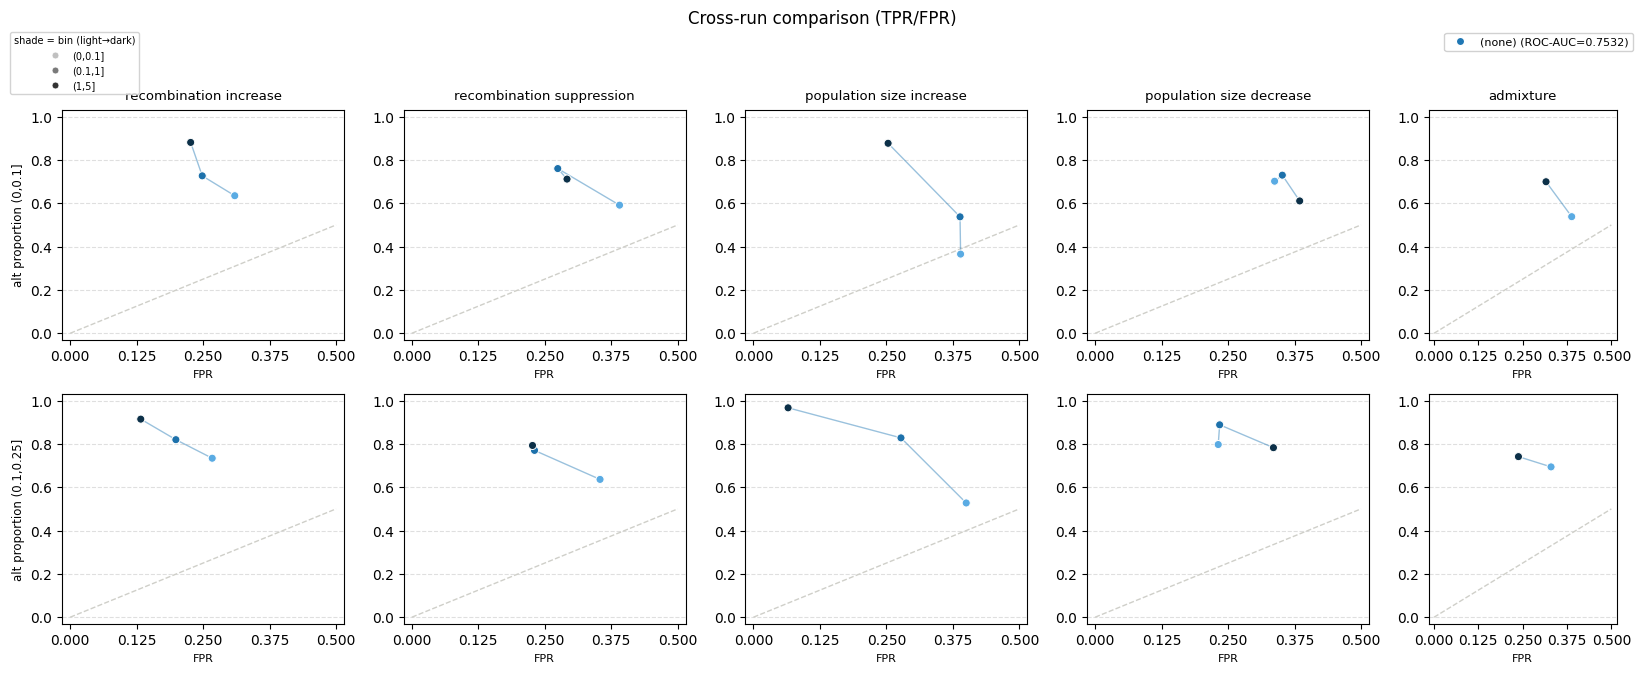

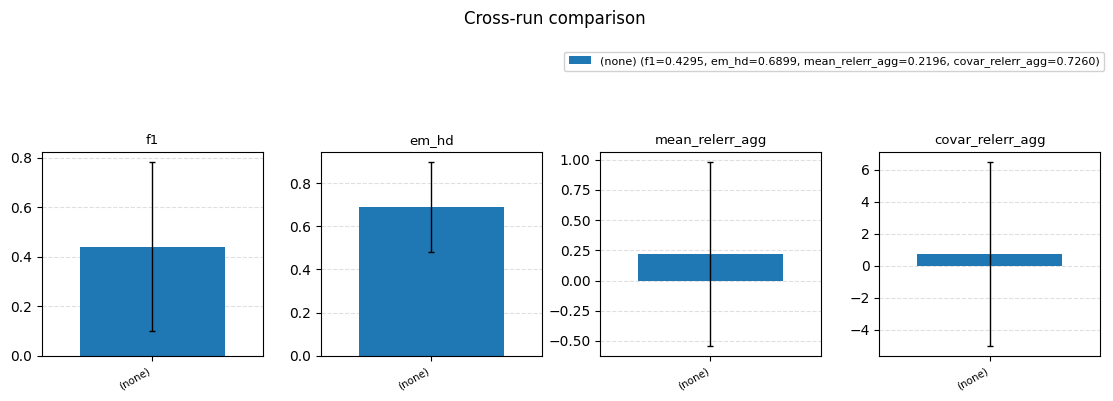

In [ ]:
# agg=["--pair"] pools everything else into each on/off bar. No --pair runs exist
# in store/phlag yet, so this currently prints "no matching run dirs" for that side.
configs_pair = cra.resolve_configs_cartesian(
    {"--pair": True, "-d": "gaussian", "--lam": [0.0, 1.0, 1.5]},
    exclude_keywords=("tau", "boost", "gd", "diag", "shift"), agg=["--pair"],
)
cra.plot_stat(configs_pair, metrics=["tpr_fpr", "f1", "em_hd", "mean_relerr_agg", "covar_relerr_agg"])
cra.print_configs(configs_pair)